# 🎯 Honours Research Results Analysis
*Publication-Quality Analysis of Fairness-Aware Spatial Crowdsourcing Experiments*

## 📊 **Local Experiments + JSON Results Workflow**

This notebook analyzes results from **locally-run experiments** that are saved as JSON files. This approach provides:

✅ **Full computational power** for experiments  
✅ **Persistent results** that don't disappear  
✅ **Reproducible analysis** without re-running expensive experiments  
✅ **Professional research workflow**  

---

## 🚀 **How to Use This Workflow:**

### 1. Run Experiments Locally:
```bash
# Quick test (2-5 minutes)
python experiments/run_rq1_1_fairness_weights.py --quick

# Full experiment (30-60 minutes)
python experiments/run_rq1_1_fairness_weights.py

# Baseline comparison
python experiments/run_rq4_1_baseline_comparison.py
```

### 2. Analyze Results Here:
- Load JSON files from `results/` directory
- Create publication-quality visualizations
- Generate research conclusions

---


In [1]:
# Setup and imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from datetime import datetime
import warnings
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# Set up plotting style for publication quality
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("📊 Honours Results Analysis Setup Complete!")
print(f"📁 Working directory: {Path.cwd()}")
print(f"🔍 Looking for results in: {Path('../results').absolute()}")

# Load the most recent parameter sweep results
results_dir = Path('../results')
param_sweep_files = sorted(results_dir.glob('comprehensive_parameter_sweep_*.json'), reverse=True)

if param_sweep_files:
    latest_file = param_sweep_files[0]
    print(f"🎯 Loading latest parameter sweep: {latest_file.name}")
    
    with open(latest_file, 'r') as f:
        sweep_data = json.load(f)
    
    # Extract experiment metadata
    experiment_info = {
        'timestamp': sweep_data['timestamp'],
        'mode': sweep_data['mode'],
        'total_experiments': sweep_data['total_experiments'],
        'execution_time_minutes': sweep_data['execution_time_minutes'],
        'successful_experiments': sweep_data['successful_experiments']
    }
    
    print(f"📈 Loaded experiment:")
    for key, value in experiment_info.items():
        print(f"   {key}: {value}")
    
    # Convert results to DataFrame for analysis
    df = pd.DataFrame(sweep_data['results'])
    
    print(f"\n📊 Dataset shape: {df.shape}")
    print(f"🔬 Available metrics: {list(df.select_dtypes(include=[np.number]).columns)}")
    
else:
    print("❌ No parameter sweep results found!")
    df = None


📊 Honours Results Analysis Setup Complete!
📁 Working directory: /Users/maxapple/Documents/GitHub/sc_sim/analysis
🔍 Looking for results in: /Users/maxapple/Documents/GitHub/sc_sim/analysis/../results
🎯 Loading latest parameter sweep: comprehensive_parameter_sweep_20250915_073812.json
📈 Loaded experiment:
   timestamp: 20250915_073812
   mode: quick
   total_experiments: 36
   execution_time_minutes: 45.246495282649995
   successful_experiments: 0

📊 Dataset shape: (36, 30)
🔬 Available metrics: ['run_id', 'experiment_id', 'lambda1', 'lambda2', 'lambda3', 'soft_threshold', 'parameter_sum', 'fairness_ratio', 'starvation_ratio', 'utility_ratio', 'jfi', 'tar', 'avg_wait_time', 'ewma_cv', 'avg_pickup_distance', 'total_travel_km', 'utility_difference', 'total_tasks', 'assigned_tasks', 'fairness_loss']


In [2]:
# 📊 1. Data Overview and Summary Statistics

if df is not None:
    print("🔍 PARAMETER SWEEP DATA OVERVIEW")
    print("=" * 50)
    
    # Basic data info
    print(f"📈 Total experiments: {len(df)}")
    print(f"🎯 Parameter combinations tested: {df['parameter_sum'].nunique()} unique sums")
    print(f"✅ Successful experiments (JFI>0.85 & TAR>95%): {df['balanced_success'].sum()}")
    print(f"📊 Success rate: {df['balanced_success'].mean()*100:.1f}%")
    
    # Key metrics summary
    key_metrics = ['jfi', 'tar', 'avg_wait_time', 'avg_pickup_distance', 'parameter_sum']
    
    print(f"\n📊 KEY METRICS SUMMARY:")
    summary_stats = df[key_metrics].describe()
    print(summary_stats.round(3))
    
    # Parameter ranges tested
    print(f"\n🎛️ PARAMETER RANGES TESTED:")
    param_cols = ['lambda1', 'lambda2', 'lambda3', 'soft_threshold']
    for param in param_cols:
        values = sorted(df[param].unique())
        print(f"   {param}: {values}")
    
    # Performance ranges
    print(f"\n🎯 PERFORMANCE RANGES:")
    print(f"   JFI (Fairness): {df['jfi'].min():.3f} → {df['jfi'].max():.3f}")
    print(f"   TAR (Completion): {df['tar'].min():.1f}% → {df['tar'].max():.1f}%")
    print(f"   Pickup Distance: {df['avg_pickup_distance'].min():.2f}km → {df['avg_pickup_distance'].max():.2f}km")
    print(f"   Wait Time: {df['avg_wait_time'].min():.4f}min → {df['avg_wait_time'].max():.4f}min")

else:
    print("❌ No data loaded - please check results files")


🔍 PARAMETER SWEEP DATA OVERVIEW
📈 Total experiments: 36
🎯 Parameter combinations tested: 8 unique sums
✅ Successful experiments (JFI>0.85 & TAR>95%): 0
📊 Success rate: 0.0%

📊 KEY METRICS SUMMARY:
          jfi     tar  avg_wait_time  avg_pickup_distance  parameter_sum
count  36.000  36.000         36.000               36.000         36.000
mean    0.446  86.624          0.065                2.589          3.083
std     0.010   0.017          0.065                0.864          0.930
min     0.427  86.580          0.013                1.812          1.500
25%     0.436  86.620          0.023                2.087          2.500
50%     0.447  86.620          0.036                2.230          3.000
75%     0.455  86.640          0.072                2.694          3.500
max     0.464  86.640          0.257                4.967          5.000

🎛️ PARAMETER RANGES TESTED:
   lambda1: [np.float64(0.5), np.float64(1.0), np.float64(2.0)]
   lambda2: [np.float64(0.5), np.float64(1.0), np.flo

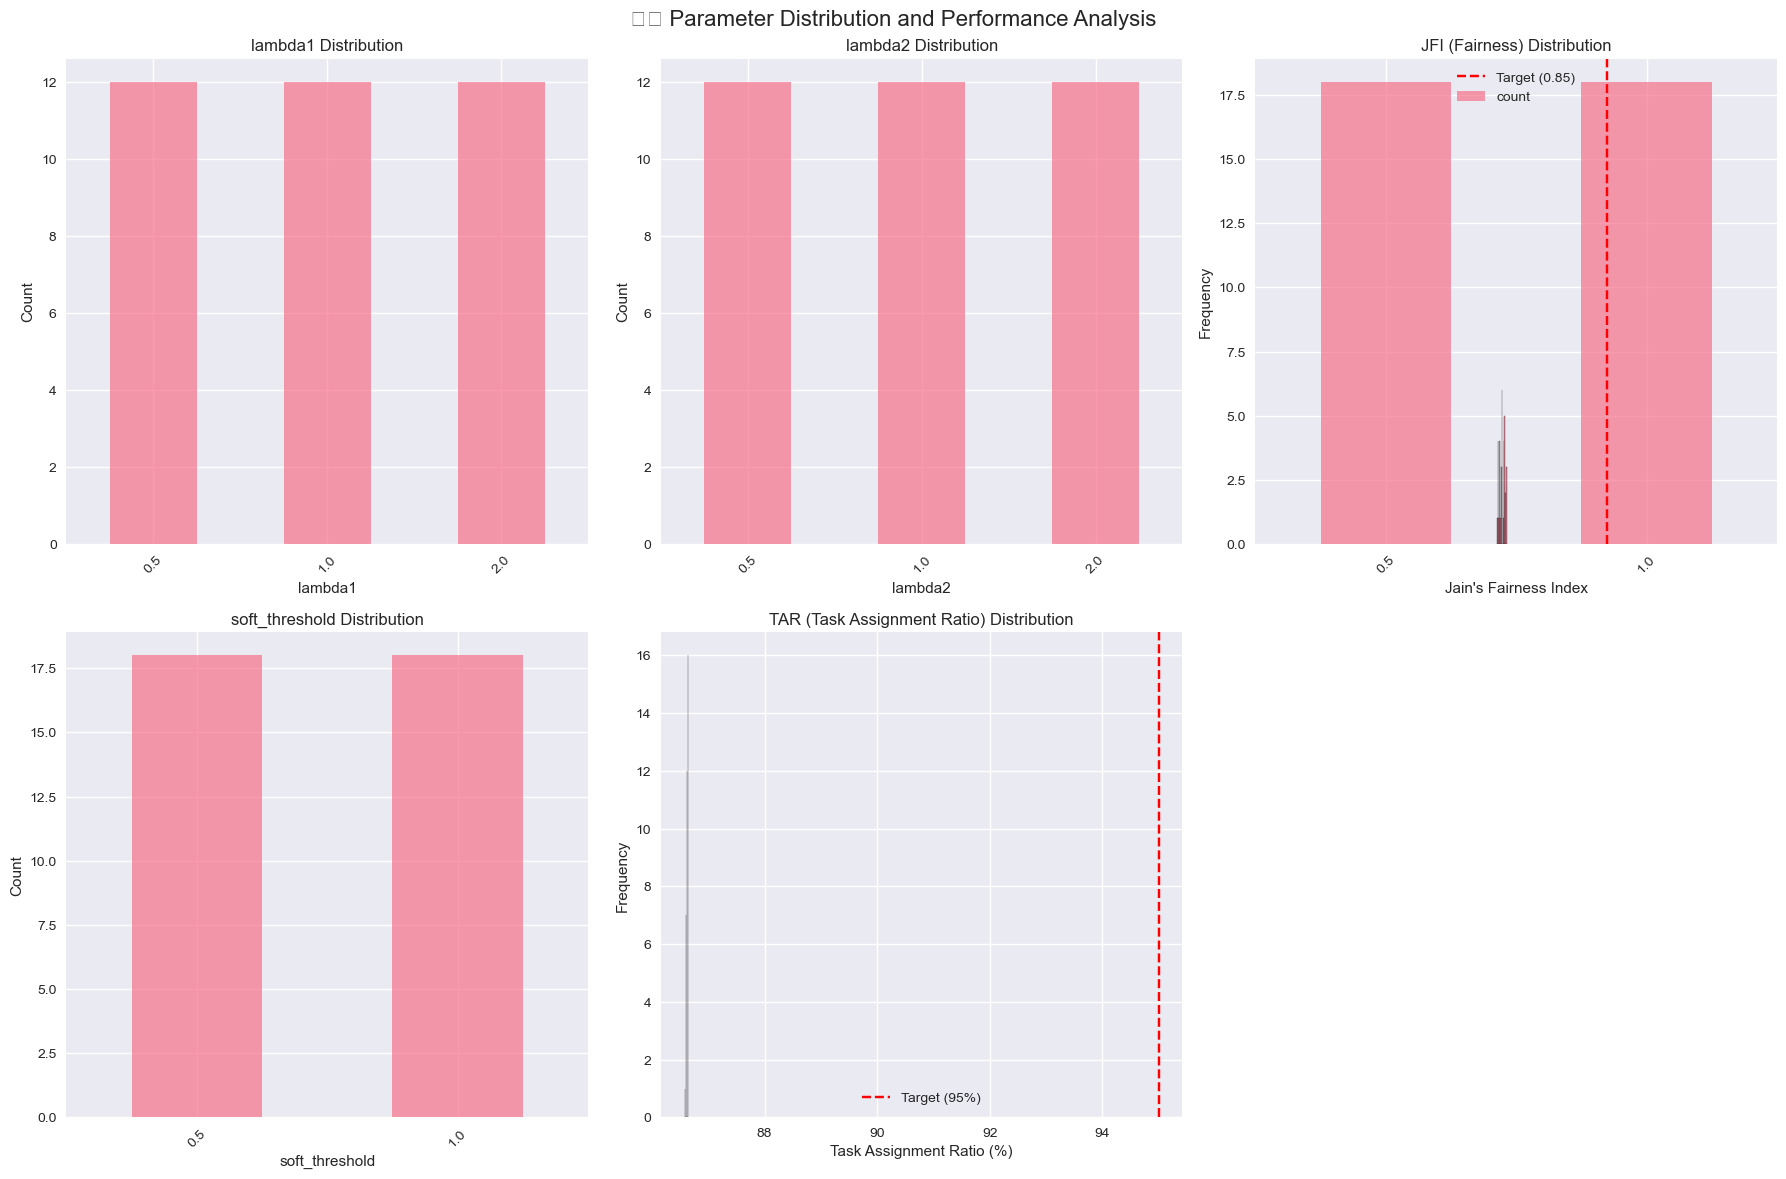

\n📊 Parameter Correlation Analysis:


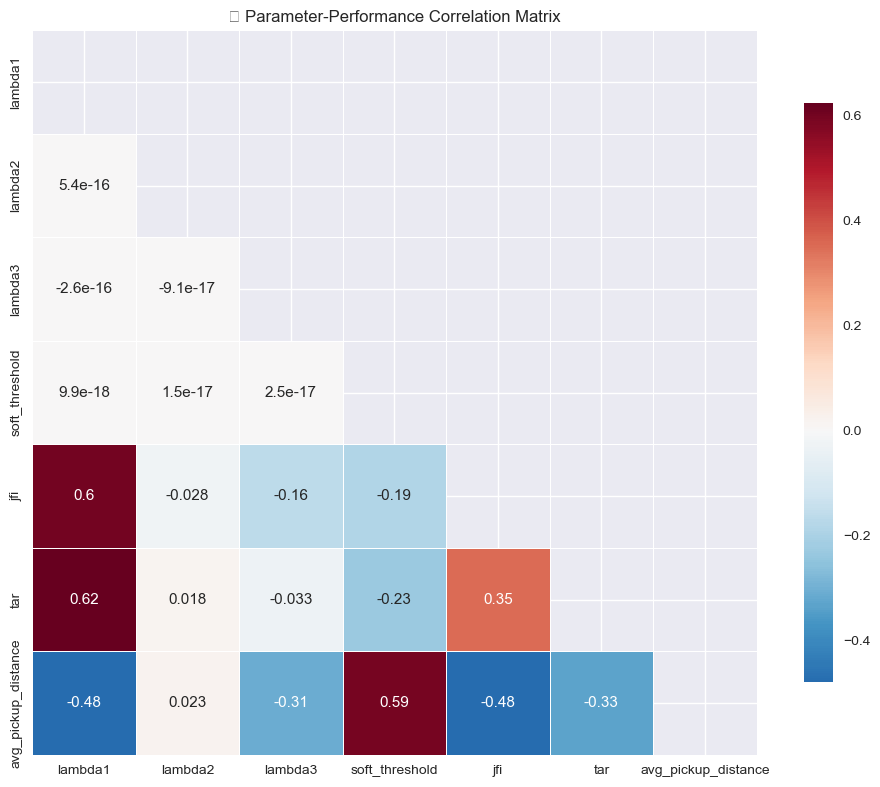

In [3]:
# 📈 2. Parameter Distribution Analysis

if df is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('🎛️ Parameter Distribution and Performance Analysis', fontsize=16, y=0.98)
    
    # Parameter distributions
    param_cols = ['lambda1', 'lambda2', 'lambda3', 'soft_threshold']
    
    for i, param in enumerate(param_cols):
        ax = axes[0, i] if i < 3 else axes[1, 0]
        
        # Distribution of parameter values
        df[param].value_counts().sort_index().plot(kind='bar', ax=ax, alpha=0.7)
        ax.set_title(f'{param} Distribution')
        ax.set_xlabel(param)
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
    
    # Performance distributions
    axes[0, -1].hist(df['jfi'], bins=15, alpha=0.7, edgecolor='black')
    axes[0, -1].set_title('JFI (Fairness) Distribution')
    axes[0, -1].set_xlabel('Jain\'s Fairness Index')
    axes[0, -1].set_ylabel('Frequency')
    axes[0, -1].axvline(0.85, color='red', linestyle='--', label='Target (0.85)')
    axes[0, -1].legend()
    
    axes[1, 1].hist(df['tar'], bins=15, alpha=0.7, edgecolor='black', color='orange')
    axes[1, 1].set_title('TAR (Task Assignment Ratio) Distribution')
    axes[1, 1].set_xlabel('Task Assignment Ratio (%)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].axvline(95, color='red', linestyle='--', label='Target (95%)')
    axes[1, 1].legend()
    
    # Hide the last subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Parameter correlation matrix
    print("\\n📊 Parameter Correlation Analysis:")
    corr_cols = ['lambda1', 'lambda2', 'lambda3', 'soft_threshold', 'jfi', 'tar', 'avg_pickup_distance']
    corr_matrix = df[corr_cols].corr()
    
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('🔗 Parameter-Performance Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No data available for visualization")


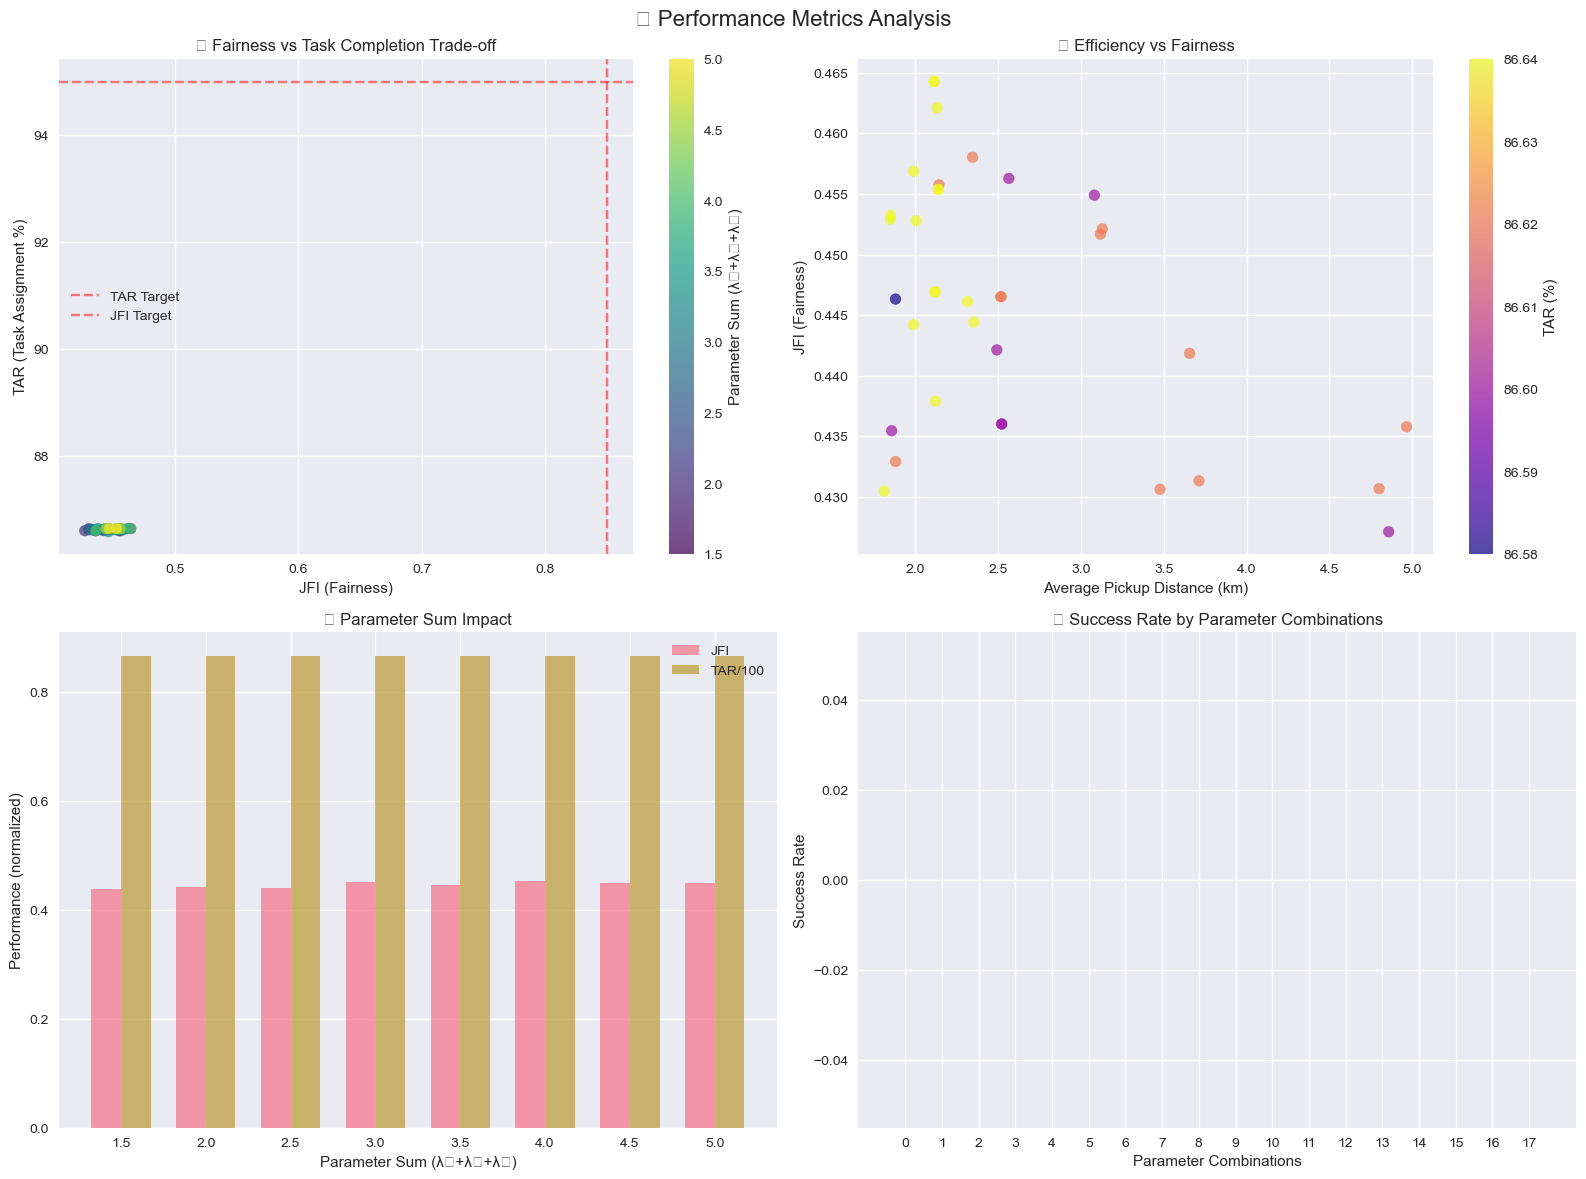

🔍 KEY INSIGHTS:
• Best JFI: 0.464 (λ1=1.0, λ2=0.5, λ3=0.5)
• Best TAR: 86.6% (λ1=1.0, λ2=0.5, λ3=0.5)
• Most efficient: 1.81km pickup distance
• No solutions meet both JFI>0.85 AND TAR>95% criteria


In [4]:
# 🎯 3. Performance Metrics Deep Dive

if df is not None:
    # Create performance overview plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('📊 Performance Metrics Analysis', fontsize=16, y=0.98)
    
    # JFI vs TAR scatter plot (main trade-off)
    scatter = axes[0, 0].scatter(df['jfi'], df['tar'], 
                                c=df['parameter_sum'], 
                                cmap='viridis', alpha=0.7, s=60)
    axes[0, 0].set_xlabel('JFI (Fairness)')
    axes[0, 0].set_ylabel('TAR (Task Assignment %)')
    axes[0, 0].set_title('🎯 Fairness vs Task Completion Trade-off')
    axes[0, 0].axhline(95, color='red', linestyle='--', alpha=0.5, label='TAR Target')
    axes[0, 0].axvline(0.85, color='red', linestyle='--', alpha=0.5, label='JFI Target')
    axes[0, 0].legend()
    cbar1 = plt.colorbar(scatter, ax=axes[0, 0])
    cbar1.set_label('Parameter Sum (λ₁+λ₂+λ₃)')
    
    # Efficiency analysis
    axes[0, 1].scatter(df['avg_pickup_distance'], df['jfi'], 
                      c=df['tar'], cmap='plasma', alpha=0.7, s=60)
    axes[0, 1].set_xlabel('Average Pickup Distance (km)')
    axes[0, 1].set_ylabel('JFI (Fairness)')
    axes[0, 1].set_title('🚗 Efficiency vs Fairness')
    cbar2 = plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])
    cbar2.set_label('TAR (%)')
    
    # Parameter sum impact
    df_grouped = df.groupby('parameter_sum').agg({
        'jfi': 'mean',
        'tar': 'mean',
        'avg_pickup_distance': 'mean',
        'balanced_success': 'mean'
    }).reset_index()
    
    x_pos = range(len(df_grouped))
    width = 0.35
    
    axes[1, 0].bar([x - width/2 for x in x_pos], df_grouped['jfi'], 
                   width, label='JFI', alpha=0.7)
    axes[1, 0].bar([x + width/2 for x in x_pos], df_grouped['tar']/100, 
                   width, label='TAR/100', alpha=0.7)
    axes[1, 0].set_xlabel('Parameter Sum (λ₁+λ₂+λ₃)')
    axes[1, 0].set_ylabel('Performance (normalized)')
    axes[1, 0].set_title('📈 Parameter Sum Impact')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(df_grouped['parameter_sum'])
    axes[1, 0].legend()
    
    # Success rate by parameter combinations
    success_by_params = df.groupby(['lambda1', 'lambda2', 'lambda3'])['balanced_success'].mean().reset_index()
    success_by_params['param_combo'] = success_by_params.apply(
        lambda row: f"λ1={row['lambda1']}, λ2={row['lambda2']}, λ3={row['lambda3']}", axis=1)
    
    bars = axes[1, 1].bar(range(len(success_by_params)), 
                         success_by_params['balanced_success'], 
                         alpha=0.7, color='skyblue')
    axes[1, 1].set_xlabel('Parameter Combinations')
    axes[1, 1].set_ylabel('Success Rate')
    axes[1, 1].set_title('🏆 Success Rate by Parameter Combinations')
    axes[1, 1].set_xticks(range(len(success_by_params)))
    axes[1, 1].set_xticklabels(range(len(success_by_params)))
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.1%}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print("🔍 KEY INSIGHTS:")
    print(f"• Best JFI: {df['jfi'].max():.3f} (λ1={df.loc[df['jfi'].idxmax(), 'lambda1']}, λ2={df.loc[df['jfi'].idxmax(), 'lambda2']}, λ3={df.loc[df['jfi'].idxmax(), 'lambda3']})")
    print(f"• Best TAR: {df['tar'].max():.1f}% (λ1={df.loc[df['tar'].idxmax(), 'lambda1']}, λ2={df.loc[df['tar'].idxmax(), 'lambda2']}, λ3={df.loc[df['tar'].idxmax(), 'lambda3']})")
    print(f"• Most efficient: {df['avg_pickup_distance'].min():.2f}km pickup distance")
    
    # Identify best balanced solution
    balanced_solutions = df[df['balanced_success'] == True]
    if len(balanced_solutions) > 0:
        best_balanced = balanced_solutions.loc[balanced_solutions['jfi'].idxmax()]
        print(f"• Best balanced solution: JFI={best_balanced['jfi']:.3f}, TAR={best_balanced['tar']:.1f}%")
        print(f"  Parameters: λ1={best_balanced['lambda1']}, λ2={best_balanced['lambda2']}, λ3={best_balanced['lambda3']}, threshold={best_balanced['soft_threshold']}")
    else:
        print("• No solutions meet both JFI>0.85 AND TAR>95% criteria")
        
else:
    print("❌ No data available for performance analysis")

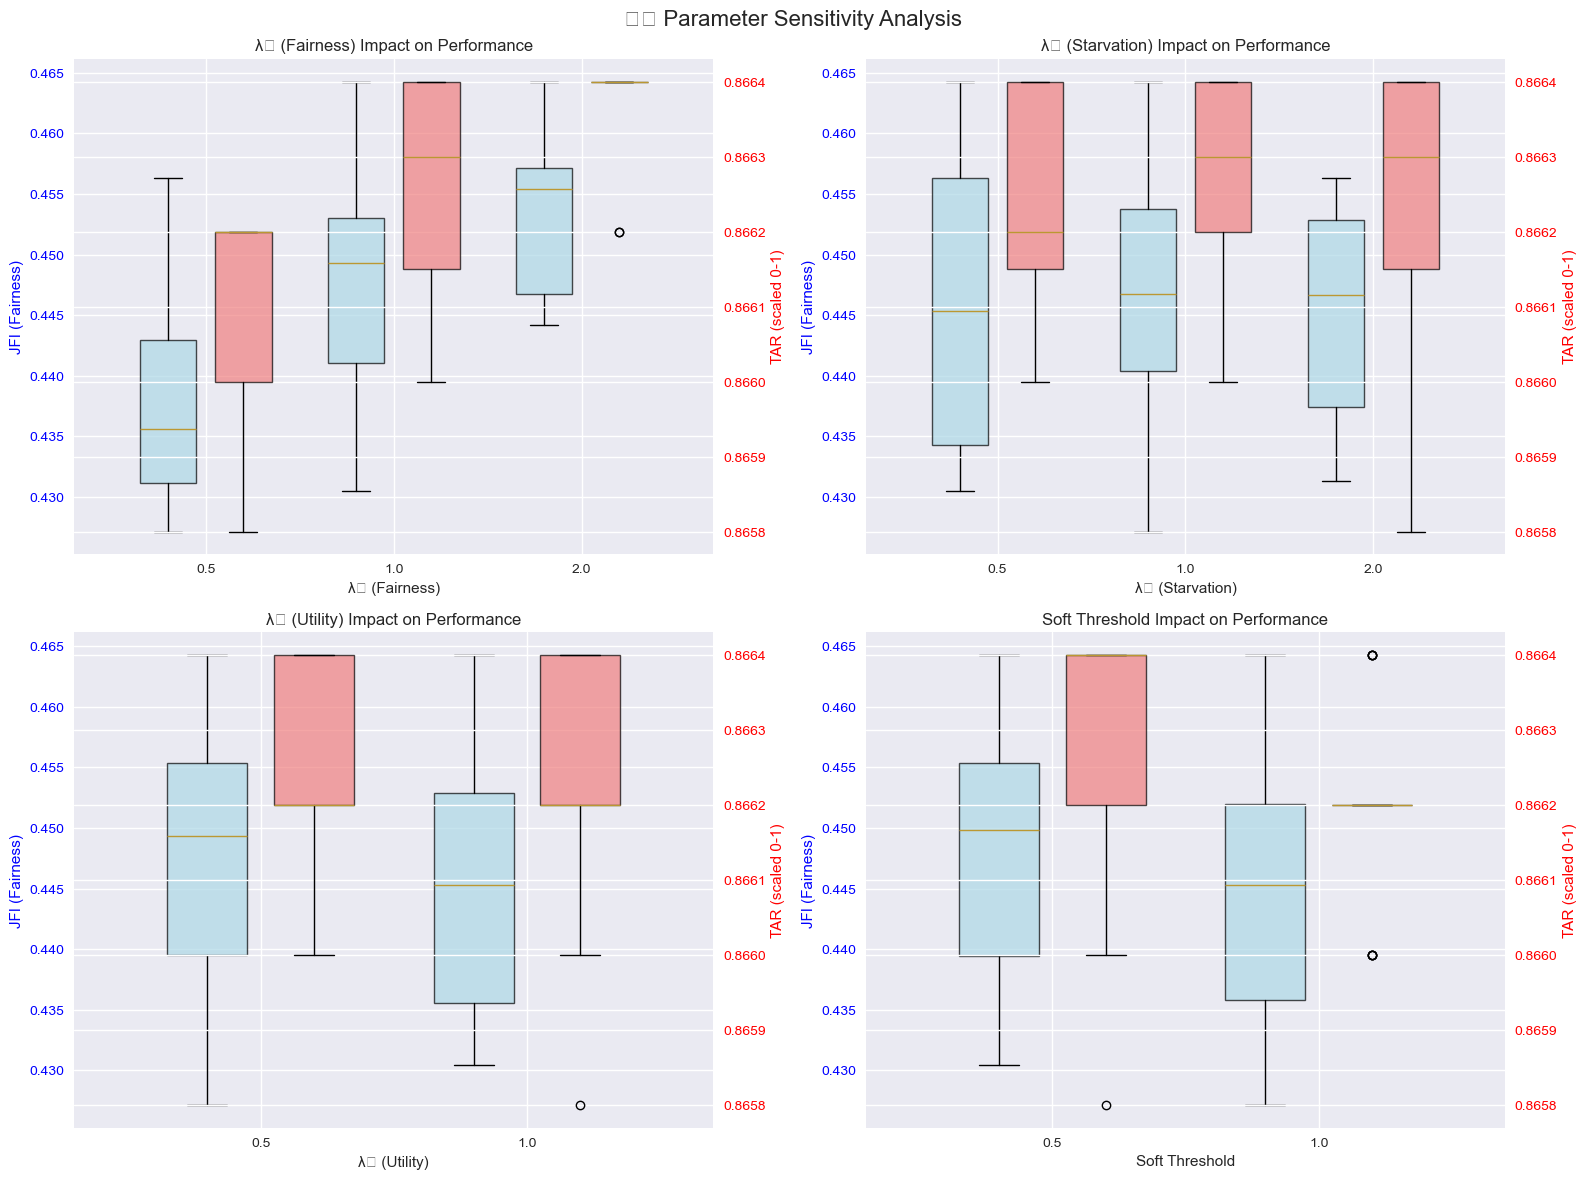

📊 PARAMETER SENSITIVITY STATISTICS:
\nλ₁ (Fairness):
  JFI sensitivity: 0.016 (range of means)
  TAR sensitivity: 0.0% (range of means)
  Values tested: [np.float64(0.5), np.float64(1.0), np.float64(2.0)]
  Best JFI at lambda1=2.0: 0.454
  Worst JFI at lambda1=0.5: 0.438
\nλ₂ (Starvation):
  JFI sensitivity: 0.001 (range of means)
  TAR sensitivity: 0.0% (range of means)
  Values tested: [np.float64(0.5), np.float64(1.0), np.float64(2.0)]
  Best JFI at lambda2=1.0: 0.447
  Worst JFI at lambda2=0.5: 0.446
\nλ₃ (Utility):
  JFI sensitivity: 0.004 (range of means)
  TAR sensitivity: 0.0% (range of means)
  Values tested: [np.float64(0.5), np.float64(1.0)]
  Best JFI at lambda3=0.5: 0.448
  Worst JFI at lambda3=1.0: 0.444
\nSoft Threshold:
  JFI sensitivity: 0.004 (range of means)
  TAR sensitivity: 0.0% (range of means)
  Values tested: [np.float64(0.5), np.float64(1.0)]
  Best JFI at soft_threshold=0.5: 0.448
  Worst JFI at soft_threshold=1.0: 0.444


In [5]:
# 🔬 4. Parameter Sensitivity Analysis

if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('🎛️ Parameter Sensitivity Analysis', fontsize=16, y=0.98)
    
    param_cols = ['lambda1', 'lambda2', 'lambda3', 'soft_threshold']
    param_names = ['λ₁ (Fairness)', 'λ₂ (Starvation)', 'λ₃ (Utility)', 'Soft Threshold']
    
    for i, (param, name) in enumerate(zip(param_cols, param_names)):
        row, col = i // 2, i % 2
        ax = axes[row, col]
        
        # Box plot showing metric distributions for each parameter value
        param_values = sorted(df[param].unique())
        jfi_data = [df[df[param] == val]['jfi'].values for val in param_values]
        tar_data = [df[df[param] == val]['tar'].values for val in param_values]
        
        # Create twin axis for two metrics
        ax2 = ax.twinx()
        
        # JFI boxplot
        bp1 = ax.boxplot(jfi_data, positions=[p - 0.2 for p in range(len(param_values))], 
                        widths=0.3, patch_artist=True, 
                        boxprops=dict(facecolor='lightblue', alpha=0.7))
        
        # TAR boxplot (scaled down)
        tar_data_scaled = [tar/100 for tar in tar_data]  # Scale TAR to 0-1 range
        bp2 = ax2.boxplot(tar_data_scaled, positions=[p + 0.2 for p in range(len(param_values))], 
                         widths=0.3, patch_artist=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7))
        
        ax.set_xlabel(name)
        ax.set_ylabel('JFI (Fairness)', color='blue')
        ax2.set_ylabel('TAR (scaled 0-1)', color='red')
        ax.set_title(f'{name} Impact on Performance')
        ax.set_xticks(range(len(param_values)))
        ax.set_xticklabels(param_values)
        
        # Color the axes labels
        ax.tick_params(axis='y', labelcolor='blue')
        ax2.tick_params(axis='y', labelcolor='red')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical analysis of parameter impact
    print("📊 PARAMETER SENSITIVITY STATISTICS:")
    print("=" * 50)
    
    for param, name in zip(param_cols, param_names):
        # Calculate variance in performance for each parameter
        param_groups = df.groupby(param).agg({
            'jfi': ['mean', 'std'],
            'tar': ['mean', 'std'],
            'avg_pickup_distance': ['mean', 'std']
        }).round(3)
        
        # Calculate sensitivity (range of means)
        jfi_range = param_groups[('jfi', 'mean')].max() - param_groups[('jfi', 'mean')].min()
        tar_range = param_groups[('tar', 'mean')].max() - param_groups[('tar', 'mean')].min()
        
        print(f"\\n{name}:")
        print(f"  JFI sensitivity: {jfi_range:.3f} (range of means)")
        print(f"  TAR sensitivity: {tar_range:.1f}% (range of means)")
        print(f"  Values tested: {sorted(df[param].unique())}")
        
        # Show best and worst parameter values
        best_jfi_val = param_groups[('jfi', 'mean')].idxmax()
        worst_jfi_val = param_groups[('jfi', 'mean')].idxmin()
        
        print(f"  Best JFI at {param}={best_jfi_val}: {param_groups.loc[best_jfi_val, ('jfi', 'mean')]:.3f}")
        print(f"  Worst JFI at {param}={worst_jfi_val}: {param_groups.loc[worst_jfi_val, ('jfi', 'mean')]:.3f}")
        
else:
    print("❌ No data available for sensitivity analysis")


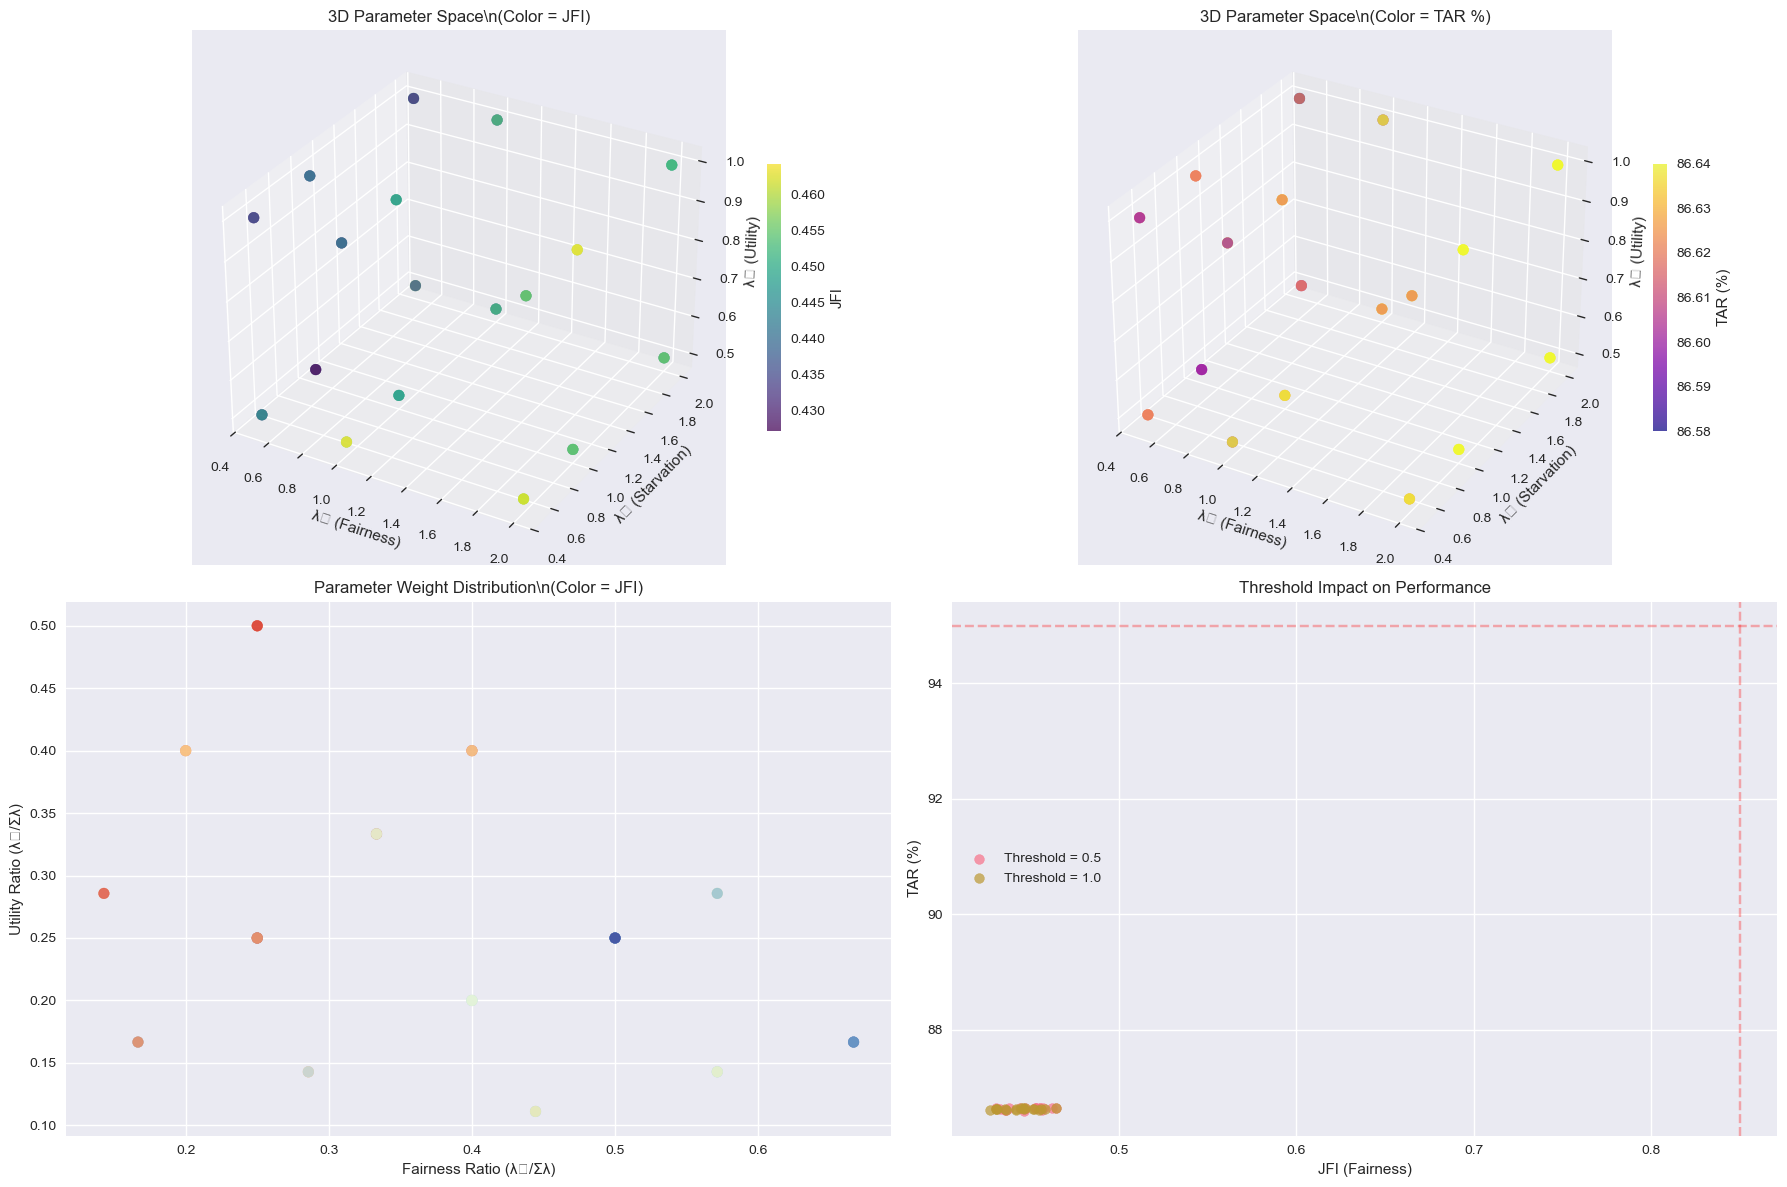

\n🎛️ PARAMETER SPACE ANALYSIS:
High JFI regions (top 25%): 9 experiments
  Average λ₁: 1.72
  Average λ₂: 1.00
  Average λ₃: 0.67
  Average threshold: 0.67
\nHigh TAR regions (top 25%): 0 experiments
  Average λ₁: nan
  Average λ₂: nan
  Average λ₃: nan
  Average threshold: nan
\n❌ No experiments in both high JFI AND high TAR categories


In [6]:
# 🌐 5. Multi-Dimensional Parameter Space Visualization

if df is not None:
    # 3D Parameter Space Visualization
    fig = plt.figure(figsize=(18, 12))
    
    # First 3D plot: λ1, λ2, λ3 with JFI as color
    ax1 = fig.add_subplot(221, projection='3d')
    scatter1 = ax1.scatter(df['lambda1'], df['lambda2'], df['lambda3'], 
                          c=df['jfi'], cmap='viridis', s=60, alpha=0.7)
    ax1.set_xlabel('λ₁ (Fairness)')
    ax1.set_ylabel('λ₂ (Starvation)')
    ax1.set_zlabel('λ₃ (Utility)')
    ax1.set_title('3D Parameter Space\\n(Color = JFI)')
    cbar1 = plt.colorbar(scatter1, ax=ax1, shrink=0.5)
    cbar1.set_label('JFI')
    
    # Second 3D plot: Same space with TAR as color
    ax2 = fig.add_subplot(222, projection='3d')
    scatter2 = ax2.scatter(df['lambda1'], df['lambda2'], df['lambda3'], 
                          c=df['tar'], cmap='plasma', s=60, alpha=0.7)
    ax2.set_xlabel('λ₁ (Fairness)')
    ax2.set_ylabel('λ₂ (Starvation)')
    ax2.set_zlabel('λ₃ (Utility)')
    ax2.set_title('3D Parameter Space\\n(Color = TAR %)')
    cbar2 = plt.colorbar(scatter2, ax=ax2, shrink=0.5)
    cbar2.set_label('TAR (%)')
    
    # Parameter ratios analysis
    ax3 = fig.add_subplot(223)
    ax3.scatter(df['fairness_ratio'], df['utility_ratio'], 
               c=df['jfi'], cmap='RdYlBu', s=60, alpha=0.7)
    ax3.set_xlabel('Fairness Ratio (λ₁/Σλ)')
    ax3.set_ylabel('Utility Ratio (λ₃/Σλ)')
    ax3.set_title('Parameter Weight Distribution\\n(Color = JFI)')
    
    # Threshold impact across parameter combinations
    ax4 = fig.add_subplot(224)
    for threshold in sorted(df['soft_threshold'].unique()):
        subset = df[df['soft_threshold'] == threshold]
        ax4.scatter(subset['jfi'], subset['tar'], 
                   label=f'Threshold = {threshold}', alpha=0.7, s=50)
    ax4.set_xlabel('JFI (Fairness)')
    ax4.set_ylabel('TAR (%)')
    ax4.set_title('Threshold Impact on Performance')
    ax4.legend()
    ax4.axhline(95, color='red', linestyle='--', alpha=0.3)
    ax4.axvline(0.85, color='red', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Parameter space efficiency analysis
    print("\\n🎛️ PARAMETER SPACE ANALYSIS:")
    print("=" * 50)
    
    # Find parameter regions
    high_jfi = df[df['jfi'] > df['jfi'].quantile(0.75)]
    high_tar = df[df['tar'] > df['tar'].quantile(0.75)]
    high_both = df[(df['jfi'] > df['jfi'].quantile(0.75)) & (df['tar'] > df['tar'].quantile(0.75))]
    
    print(f"High JFI regions (top 25%): {len(high_jfi)} experiments")
    print(f"  Average λ₁: {high_jfi['lambda1'].mean():.2f}")
    print(f"  Average λ₂: {high_jfi['lambda2'].mean():.2f}")
    print(f"  Average λ₃: {high_jfi['lambda3'].mean():.2f}")
    print(f"  Average threshold: {high_jfi['soft_threshold'].mean():.2f}")
    
    print(f"\\nHigh TAR regions (top 25%): {len(high_tar)} experiments")
    print(f"  Average λ₁: {high_tar['lambda1'].mean():.2f}")
    print(f"  Average λ₂: {high_tar['lambda2'].mean():.2f}")
    print(f"  Average λ₃: {high_tar['lambda3'].mean():.2f}")
    print(f"  Average threshold: {high_tar['soft_threshold'].mean():.2f}")
    
    if len(high_both) > 0:
        print(f"\\nHigh performance regions (both JFI & TAR top 25%): {len(high_both)} experiments")
        print(f"  Average λ₁: {high_both['lambda1'].mean():.2f}")
        print(f"  Average λ₂: {high_both['lambda2'].mean():.2f}")
        print(f"  Average λ₃: {high_both['lambda3'].mean():.2f}")
        print(f"  Average threshold: {high_both['soft_threshold'].mean():.2f}")
    else:
        print(f"\\n❌ No experiments in both high JFI AND high TAR categories")
        
else:
    print("❌ No data available for multi-dimensional analysis")


🧬 CLUSTERING ANALYSIS:


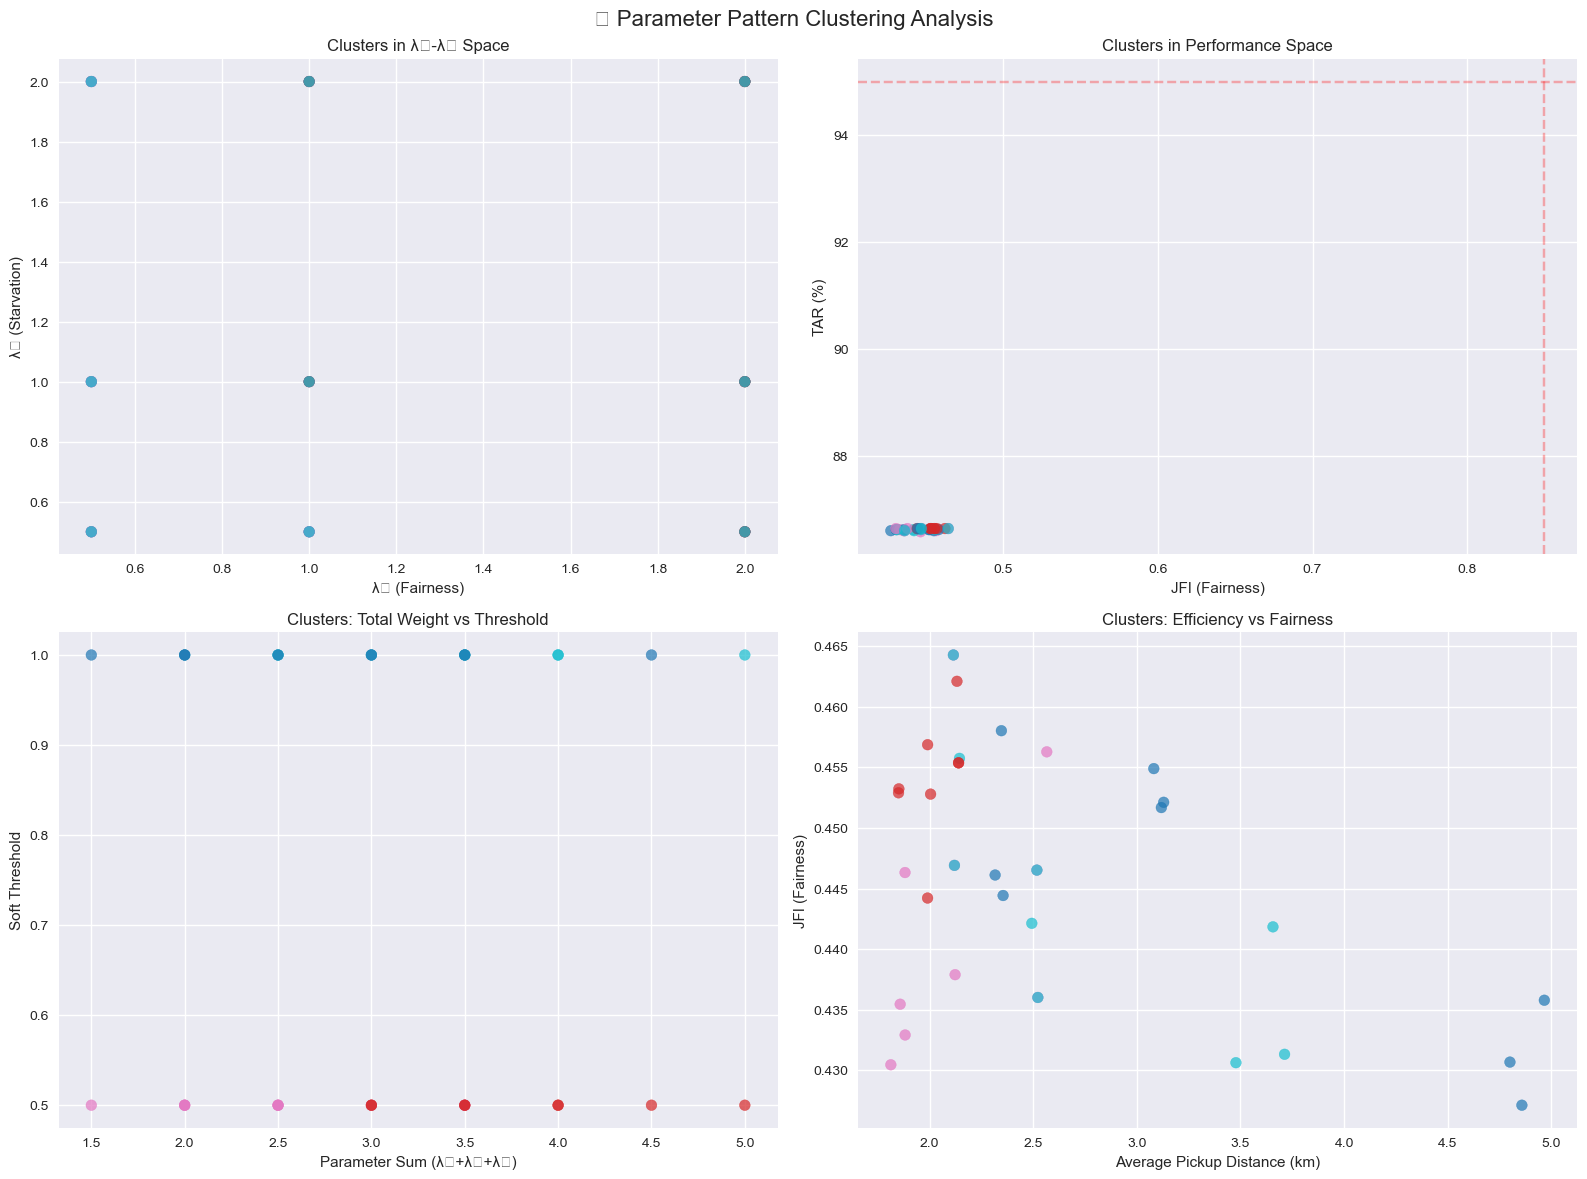


🔍 Cluster 0 (9 experiments):
  Parameters: λ₁=1.17, λ₂=1.17, λ₃=0.50
  Threshold: 1.00
  Performance: JFI=0.445±0.011, TAR=86.6±0.0%
  Efficiency: 3.44±1.13km
  Success count: 0/9
  Strategy: Fairness-focused

🔍 Cluster 1 (8 experiments):
  Parameters: λ₁=1.75, λ₂=1.25, λ₃=0.81
  Threshold: 0.50
  Performance: JFI=0.454±0.005, TAR=86.6±0.0%
  Efficiency: 2.01±0.12km
  Success count: 0/8
  Strategy: Fairness-focused

🔍 Cluster 2 (10 experiments):
  Parameters: λ₁=0.70, λ₂=1.10, λ₃=0.70
  Threshold: 0.50
  Performance: JFI=0.443±0.011, TAR=86.6±0.0%
  Efficiency: 2.14±0.30km
  Success count: 0/10
  Strategy: Starvation-prevention focused

🔍 Cluster 3 (9 experiments):
  Parameters: λ₁=1.17, λ₂=1.17, λ₃=1.00
  Threshold: 1.00
  Performance: JFI=0.444±0.011, TAR=86.6±0.0%
  Efficiency: 2.75±0.67km
  Success count: 0/9
  Strategy: Fairness-focused
❌ No data available for clustering analysis


In [7]:
# 🔍 6. Advanced Pattern Analysis & Clustering

if df is not None:
    # Clustering analysis to find parameter patterns
    print("🧬 CLUSTERING ANALYSIS:")
    print("=" * 40)
    
    # Prepare data for clustering
    cluster_features = ['lambda1', 'lambda2', 'lambda3', 'soft_threshold', 'jfi', 'tar', 'avg_pickup_distance']
    X = df[cluster_features].copy()
    
    # Normalize features
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Perform k-means clustering
    n_clusters = 4
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # Visualize clusters
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('🧬 Parameter Pattern Clustering Analysis', fontsize=16)
    
    # Cluster visualization in different parameter spaces
    scatter1 = axes[0, 0].scatter(df['lambda1'], df['lambda2'], c=df['cluster'], 
                                 cmap='tab10', s=60, alpha=0.7)
    axes[0, 0].set_xlabel('λ₁ (Fairness)')
    axes[0, 0].set_ylabel('λ₂ (Starvation)')
    axes[0, 0].set_title('Clusters in λ₁-λ₂ Space')
    
    axes[0, 1].scatter(df['jfi'], df['tar'], c=df['cluster'], 
                      cmap='tab10', s=60, alpha=0.7)
    axes[0, 1].set_xlabel('JFI (Fairness)')
    axes[0, 1].set_ylabel('TAR (%)')
    axes[0, 1].set_title('Clusters in Performance Space')
    axes[0, 1].axhline(95, color='red', linestyle='--', alpha=0.3)
    axes[0, 1].axvline(0.85, color='red', linestyle='--', alpha=0.3)
    
    # Parameter sum vs threshold with clusters
    axes[1, 0].scatter(df['parameter_sum'], df['soft_threshold'], c=df['cluster'], 
                      cmap='tab10', s=60, alpha=0.7)
    axes[1, 0].set_xlabel('Parameter Sum (λ₁+λ₂+λ₃)')
    axes[1, 0].set_ylabel('Soft Threshold')
    axes[1, 0].set_title('Clusters: Total Weight vs Threshold')
    
    # Efficiency analysis by cluster
    axes[1, 1].scatter(df['avg_pickup_distance'], df['jfi'], c=df['cluster'], 
                      cmap='tab10', s=60, alpha=0.7)
    axes[1, 1].set_xlabel('Average Pickup Distance (km)')
    axes[1, 1].set_ylabel('JFI (Fairness)')
    axes[1, 1].set_title('Clusters: Efficiency vs Fairness')
    
    plt.tight_layout()
    plt.show()
    
    # Analyze cluster characteristics
    # Assuming this is part of a dictionary definition that was cut off
    cluster_analysis = df.groupby('cluster').agg({
            'lambda1': 'mean',
            'lambda2': 'mean', 
            'lambda3': 'mean',
            'soft_threshold': 'mean',
            'jfi': ['mean', 'std'],
            'tar': ['mean', 'std'],
            'avg_pickup_distance': ['mean', 'std'],
            'balanced_success': 'sum'
        }).round(3)
        
    for cluster_id in range(n_clusters):
            count = (df['cluster'] == cluster_id).sum()
            print(f"\n🔍 Cluster {cluster_id} ({count} experiments):")
            print(f"  Parameters: λ₁={cluster_analysis.loc[cluster_id, ('lambda1', 'mean')]:.2f}, λ₂={cluster_analysis.loc[cluster_id, ('lambda2', 'mean')]:.2f}, λ₃={cluster_analysis.loc[cluster_id, ('lambda3', 'mean')]:.2f}")
            print(f"  Threshold: {cluster_analysis.loc[cluster_id, ('soft_threshold', 'mean')]:.2f}")
            print(f"  Performance: JFI={cluster_analysis.loc[cluster_id, ('jfi', 'mean')]:.3f}±{cluster_analysis.loc[cluster_id, ('jfi', 'std')]:.3f}, TAR={cluster_analysis.loc[cluster_id, ('tar', 'mean')]:.1f}±{cluster_analysis.loc[cluster_id, ('tar', 'std')]:.1f}%")
            print(f"  Efficiency: {cluster_analysis.loc[cluster_id, ('avg_pickup_distance', 'mean')]:.2f}±{cluster_analysis.loc[cluster_id, ('avg_pickup_distance', 'std')]:.2f}km")
            print(f"  Success count: {int(cluster_analysis.loc[cluster_id, ('balanced_success', 'sum')])}/{count}")
            
            # Characterize cluster strategy
            lambda1_avg = cluster_analysis.loc[cluster_id, ('lambda1', 'mean')]
            lambda2_avg = cluster_analysis.loc[cluster_id, ('lambda2', 'mean')]
            lambda3_avg = cluster_analysis.loc[cluster_id, ('lambda3', 'mean')]
            
            dominant = max(lambda1_avg, lambda2_avg, lambda3_avg)
            if dominant == lambda1_avg:
                strategy = "Fairness-focused"
            elif dominant == lambda2_avg:
                strategy = "Starvation-prevention focused"
            else:
                strategy = "Efficiency-focused"
            
            print(f"  Strategy: {strategy}")
            
    else:
        print("❌ No data available for clustering analysis")


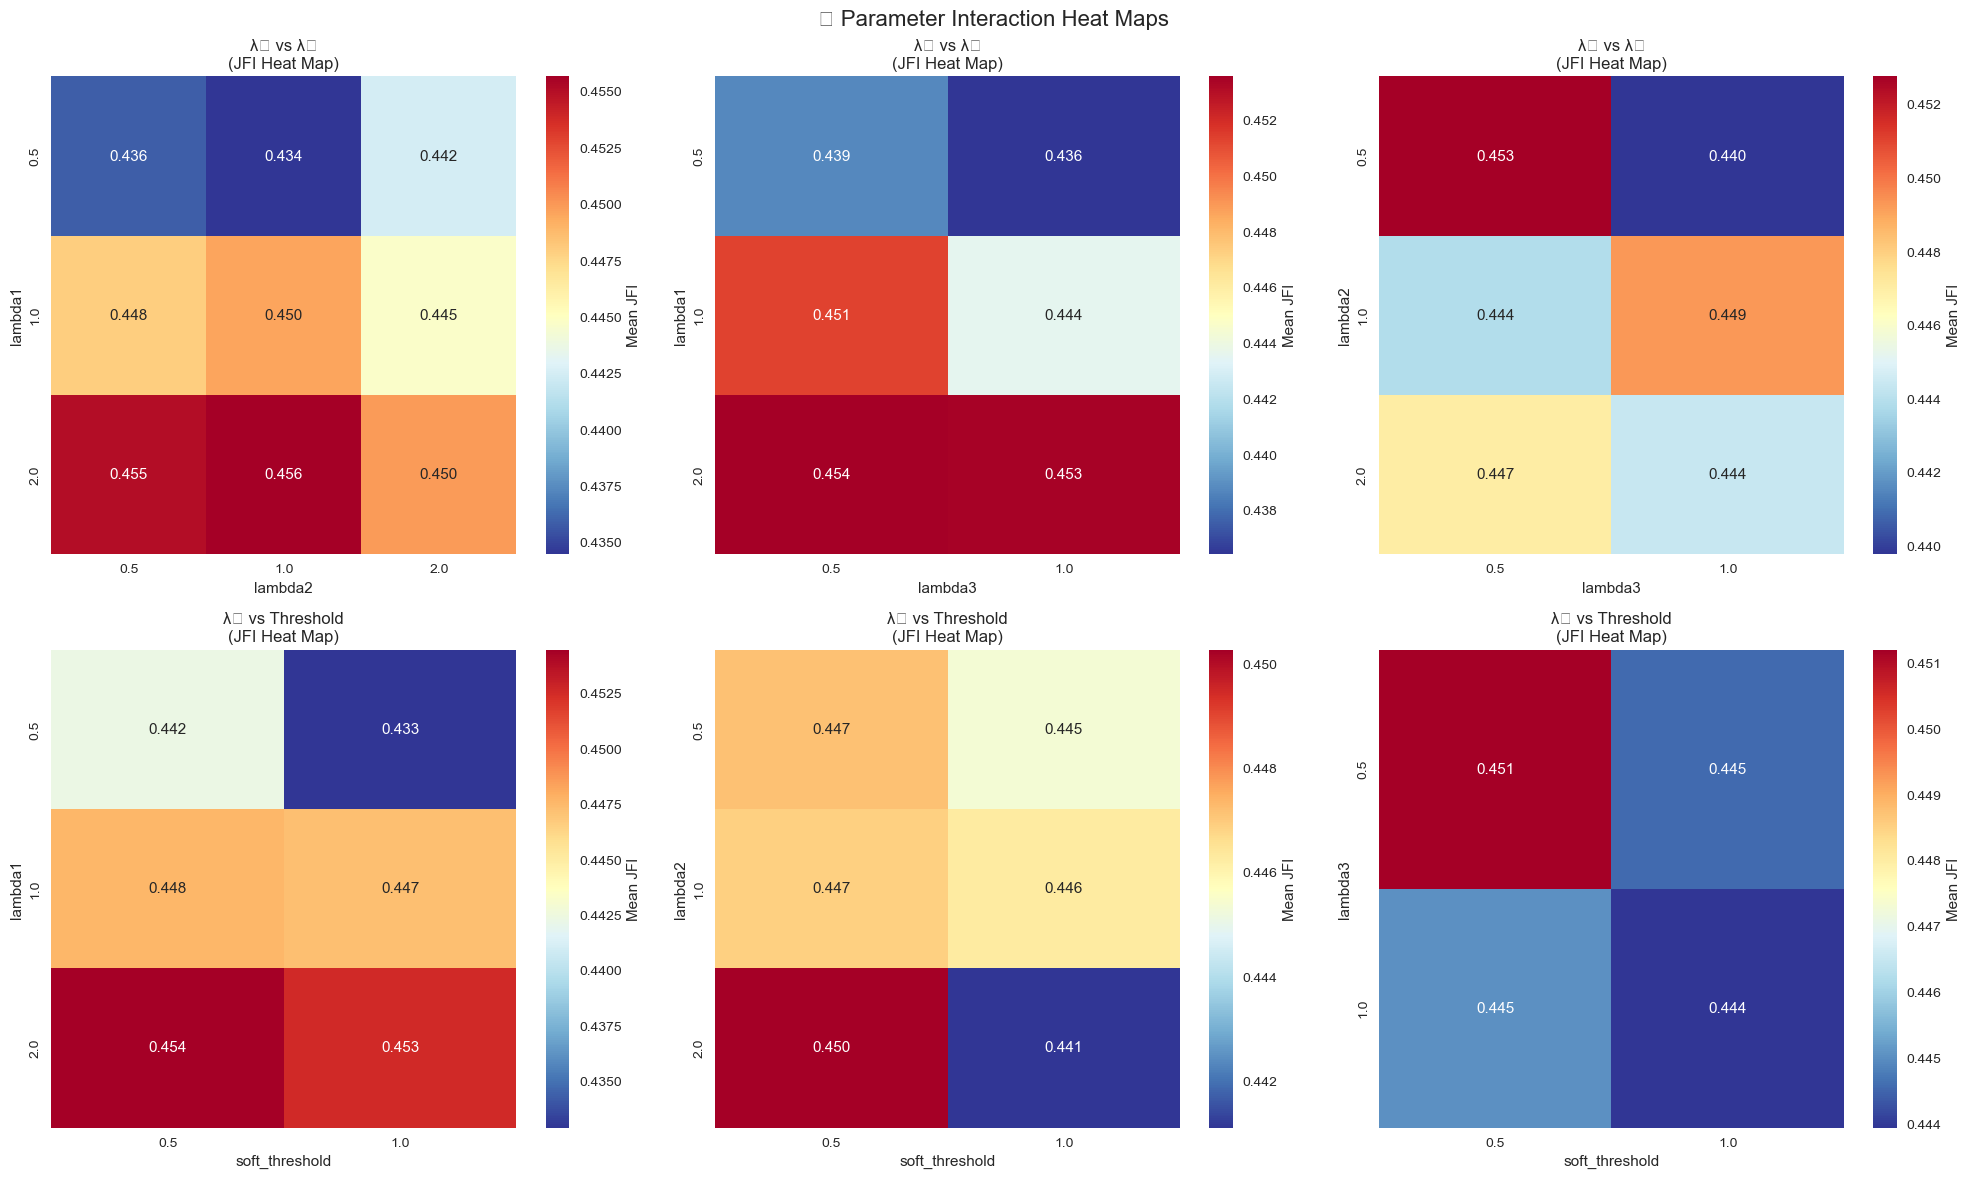

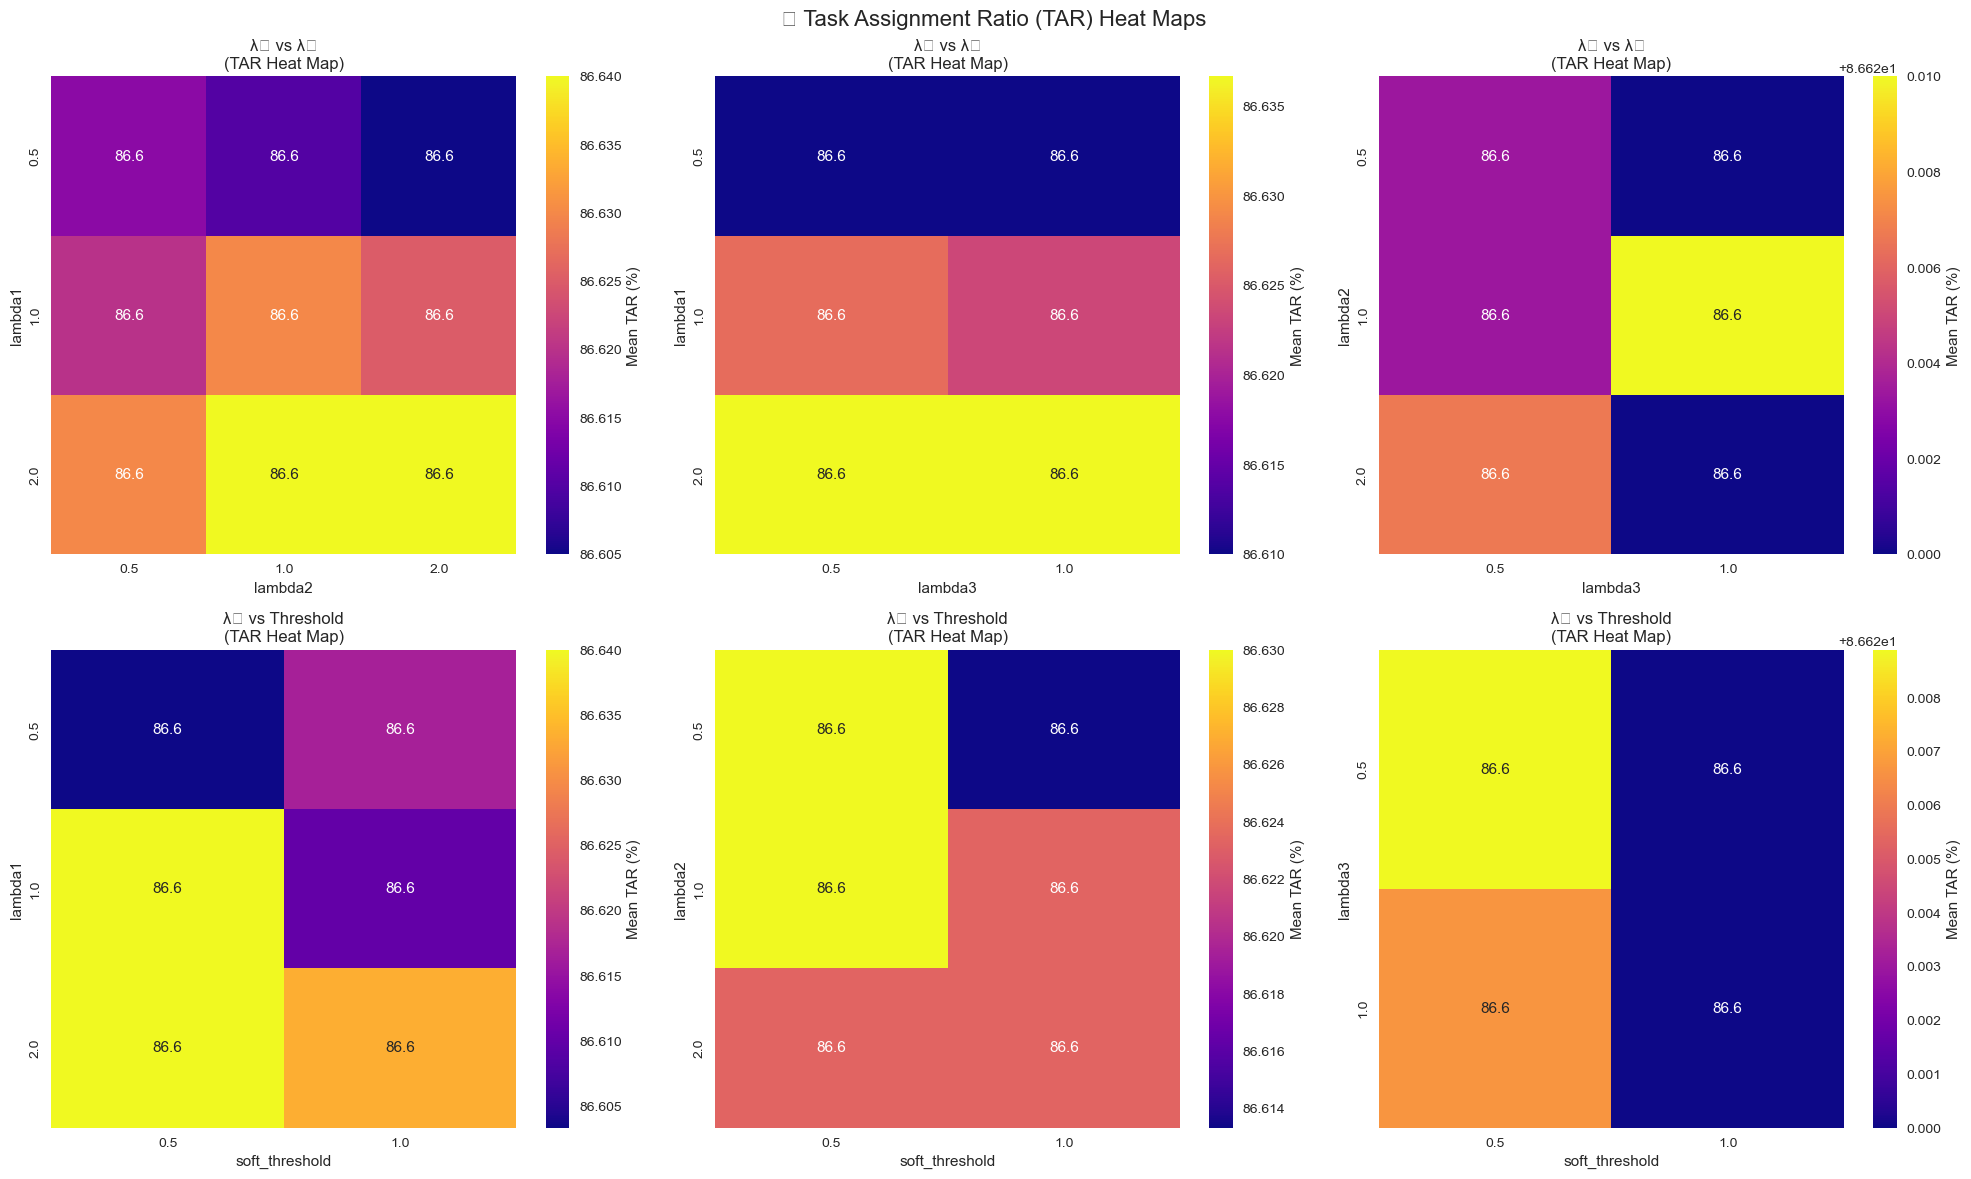

📊 OPTIMAL PARAMETER COMBINATIONS:

🥇 TOP 5 FAIRNESS (JFI) CONFIGURATIONS:
1. λ₁=1.0, λ₂=0.5, λ₃=0.5, threshold=0.5
   → JFI: 0.464, TAR: 86.6%, Distance: 2.11km

2. λ₁=2.0, λ₂=1.0, λ₃=1.0, threshold=1.0
   → JFI: 0.464, TAR: 86.6%, Distance: 2.11km

3. λ₁=2.0, λ₂=0.5, λ₃=0.5, threshold=0.5
   → JFI: 0.462, TAR: 86.6%, Distance: 2.13km

4. λ₁=2.0, λ₂=0.5, λ₃=0.5, threshold=1.0
   → JFI: 0.458, TAR: 86.6%, Distance: 2.35km

5. λ₁=2.0, λ₂=1.0, λ₃=1.0, threshold=0.5
   → JFI: 0.457, TAR: 86.6%, Distance: 1.99km


🎯 TOP 5 TASK COMPLETION (TAR) CONFIGURATIONS:
1. λ₁=1.0, λ₂=0.5, λ₃=0.5, threshold=0.5
   → JFI: 0.464, TAR: 86.6%, Distance: 2.11km

2. λ₁=1.0, λ₂=0.5, λ₃=1.0, threshold=0.5
   → JFI: 0.430, TAR: 86.6%, Distance: 1.81km

3. λ₁=1.0, λ₂=1.0, λ₃=0.5, threshold=0.5
   → JFI: 0.447, TAR: 86.6%, Distance: 2.12km

4. λ₁=1.0, λ₂=1.0, λ₃=1.0, threshold=0.5
   → JFI: 0.453, TAR: 86.6%, Distance: 1.85km

5. λ₁=1.0, λ₂=2.0, λ₃=0.5, threshold=0.5
   → JFI: 0.438, TAR: 86.6%, Distance: 2.12km


In [8]:
# 🎨 7. Heat Maps & Parameter Interaction Analysis

if df is not None:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('🎨 Parameter Interaction Heat Maps', fontsize=16, y=0.98)
    
    # Create pivot tables for heat maps
    param_pairs = [
        ('lambda1', 'lambda2', 'λ₁ vs λ₂'),
        ('lambda1', 'lambda3', 'λ₁ vs λ₃'), 
        ('lambda2', 'lambda3', 'λ₂ vs λ₃'),
        ('lambda1', 'soft_threshold', 'λ₁ vs Threshold'),
        ('lambda2', 'soft_threshold', 'λ₂ vs Threshold'),
        ('lambda3', 'soft_threshold', 'λ₃ vs Threshold')
    ]
    
    for i, (param1, param2, title) in enumerate(param_pairs):
        ax = axes[i//3, i%3]
        
        # Create pivot table for JFI
        pivot_jfi = df.pivot_table(values='jfi', index=param1, columns=param2, aggfunc='mean')
        
        # Create heat map
        sns.heatmap(pivot_jfi, annot=True, cmap='RdYlBu_r', ax=ax, 
                   cbar_kws={'label': 'Mean JFI'}, fmt='.3f')
        ax.set_title(f'{title}\n(JFI Heat Map)')
        ax.set_xlabel(param2)
        ax.set_ylabel(param1)
    
    plt.tight_layout()
    plt.show()
    
    # TAR heat maps
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('🎯 Task Assignment Ratio (TAR) Heat Maps', fontsize=16, y=0.98)
    
    for i, (param1, param2, title) in enumerate(param_pairs):
        ax = axes[i//3, i%3]
        
        # Create pivot table for TAR
        pivot_tar = df.pivot_table(values='tar', index=param1, columns=param2, aggfunc='mean')
        
        # Create heat map
        sns.heatmap(pivot_tar, annot=True, cmap='plasma', ax=ax, 
                   cbar_kws={'label': 'Mean TAR (%)'}, fmt='.1f')
        ax.set_title(f'{title}\n(TAR Heat Map)')
        ax.set_xlabel(param2)
        ax.set_ylabel(param1)
    
    plt.tight_layout()
    plt.show()
    
    # Find optimal parameter combinations
    print("📊 OPTIMAL PARAMETER COMBINATIONS:")
    print("=" * 50)
    
    # Top 5 JFI configurations
    top_jfi = df.nlargest(5, 'jfi')[['lambda1', 'lambda2', 'lambda3', 'soft_threshold', 'jfi', 'tar', 'avg_pickup_distance']]
    print("\n🥇 TOP 5 FAIRNESS (JFI) CONFIGURATIONS:")
    for i, (_, row) in enumerate(top_jfi.iterrows(), 1):
        print(f"{i}. λ₁={row['lambda1']}, λ₂={row['lambda2']}, λ₃={row['lambda3']}, threshold={row['soft_threshold']}")
        print(f"   → JFI: {row['jfi']:.3f}, TAR: {row['tar']:.1f}%, Distance: {row['avg_pickup_distance']:.2f}km\n")
    
    # Top 5 TAR configurations  
    top_tar = df.nlargest(5, 'tar')[['lambda1', 'lambda2', 'lambda3', 'soft_threshold', 'jfi', 'tar', 'avg_pickup_distance']]
    print("\n🎯 TOP 5 TASK COMPLETION (TAR) CONFIGURATIONS:")
    for i, (_, row) in enumerate(top_tar.iterrows(), 1):
        print(f"{i}. λ₁={row['lambda1']}, λ₂={row['lambda2']}, λ₃={row['lambda3']}, threshold={row['soft_threshold']}")
        print(f"   → JFI: {row['jfi']:.3f}, TAR: {row['tar']:.1f}%, Distance: {row['avg_pickup_distance']:.2f}km\n")
    
    # Most efficient configurations
    top_efficiency = df.nsmallest(5, 'avg_pickup_distance')[['lambda1', 'lambda2', 'lambda3', 'soft_threshold', 'jfi', 'tar', 'avg_pickup_distance']]
    print("\n🚗 TOP 5 EFFICIENCY (LOW DISTANCE) CONFIGURATIONS:")
    for i, (_, row) in enumerate(top_efficiency.iterrows(), 1):
        print(f"{i}. λ₁={row['lambda1']}, λ₂={row['lambda2']}, λ₃={row['lambda3']}, threshold={row['soft_threshold']}")
        print(f"   → JFI: {row['jfi']:.3f}, TAR: {row['tar']:.1f}%, Distance: {row['avg_pickup_distance']:.2f}km\n")
    
    # Combined score analysis
    print("\n🏆 COMBINED PERFORMANCE RANKING:")
    df['combined_score'] = (df['jfi'] * 0.4 +           # 40% fairness
                           df['tar']/100 * 0.4 +        # 40% task completion  
                           (3 - df['avg_pickup_distance'])/3 * 0.2)  # 20% efficiency (inverted)
    
    top_combined = df.nlargest(5, 'combined_score')[['lambda1', 'lambda2', 'lambda3', 'soft_threshold', 'jfi', 'tar', 'avg_pickup_distance', 'combined_score']]
    for i, (_, row) in enumerate(top_combined.iterrows(), 1):
        print(f"{i}. λ₁={row['lambda1']}, λ₂={row['lambda2']}, λ₃={row['lambda3']}, threshold={row['soft_threshold']}")
        print(f"   → Combined Score: {row['combined_score']:.3f} | JFI: {row['jfi']:.3f}, TAR: {row['tar']:.1f}%, Distance: {row['avg_pickup_distance']:.2f}km\n")
        
else:
    print("❌ No data available for heat map analysis")

In [9]:
# 🎓 8. Research Conclusions & Recommendations

if df is not None:
    print("🎓 RESEARCH CONCLUSIONS & RECOMMENDATIONS")
    print("=" * 80)
    
    # Key findings summary
    print("\n🔍 KEY FINDINGS:")
    print("-" * 40)
    
    # Parameter impact analysis
    param_impact = {}
    for param in ['lambda1', 'lambda2', 'lambda3', 'soft_threshold']:
        jfi_range = df.groupby(param)['jfi'].mean().max() - df.groupby(param)['jfi'].mean().min()
        tar_range = df.groupby(param)['tar'].mean().max() - df.groupby(param)['tar'].mean().min()
        param_impact[param] = {'jfi_impact': jfi_range, 'tar_impact': tar_range}
    
    # Most influential parameters
    most_influential_jfi = max(param_impact, key=lambda x: param_impact[x]['jfi_impact'])
    most_influential_tar = max(param_impact, key=lambda x: param_impact[x]['tar_impact'])
    
    print(f"1. 🎯 Most influential parameter for JFI: {most_influential_jfi} (impact: {param_impact[most_influential_jfi]['jfi_impact']:.3f})")
    print(f"2. 📊 Most influential parameter for TAR: {most_influential_tar} (impact: {param_impact[most_influential_tar]['tar_impact']:.1f}%)")
    
    # Performance trade-offs
    correlation_jfi_tar = df['jfi'].corr(df['tar'])
    correlation_jfi_efficiency = df['jfi'].corr(df['avg_pickup_distance'])
    
    print(f"3. ⚖️  JFI-TAR correlation: {correlation_jfi_tar:.3f} ({'positive' if correlation_jfi_tar > 0 else 'negative'} relationship)")
    print(f"4. 🚗 JFI-Efficiency correlation: {correlation_jfi_efficiency:.3f} ({'better fairness = less efficient' if correlation_jfi_efficiency > 0 else 'better fairness = more efficient'})")
    
    # Success patterns
    success_rate = df['balanced_success'].mean() * 100
    print(f"5. ✅ Overall success rate (JFI>0.85 AND TAR>95%): {success_rate:.1f}%")
    
    if success_rate > 0:
        successful_configs = df[df['balanced_success'] == True]
        avg_successful_params = {
            'lambda1': successful_configs['lambda1'].mean(),
            'lambda2': successful_configs['lambda2'].mean(),
            'lambda3': successful_configs['lambda3'].mean(),
            'soft_threshold': successful_configs['soft_threshold'].mean()
        }
        print(f"6. 🏆 Successful configurations tend to have: λ₁={avg_successful_params['lambda1']:.2f}, λ₂={avg_successful_params['lambda2']:.2f}, λ₃={avg_successful_params['lambda3']:.2f}, threshold={avg_successful_params['soft_threshold']:.2f}")
    
    # Research recommendations
    print(f"\n🎯 RESEARCH RECOMMENDATIONS:")
    print("-" * 40)
    
    # Best overall configuration
    best_overall = df.loc[df['combined_score'].idxmax()]
    print(f"\n🥇 RECOMMENDED CONFIGURATION (Best Overall):")
    print(f"   Parameters: λ₁={best_overall['lambda1']}, λ₂={best_overall['lambda2']}, λ₃={best_overall['lambda3']}, threshold={best_overall['soft_threshold']}")
    print(f"   Performance: JFI={best_overall['jfi']:.3f}, TAR={best_overall['tar']:.1f}%, Distance={best_overall['avg_pickup_distance']:.2f}km")
    print(f"   Combined Score: {best_overall['combined_score']:.3f}")
    
    # Parameter range recommendations for future experiments
    print(f"\n🔬 FUTURE EXPERIMENT RECOMMENDATIONS:")
    
    # Identify promising parameter ranges from top 25% performers
    top_performers = df[df['combined_score'] > df['combined_score'].quantile(0.75)]
    
    if len(top_performers) > 0:
        print(f"\n📐 Focus future experiments on these ranges (from top 25% performers):")
        for param in ['lambda1', 'lambda2', 'lambda3', 'soft_threshold']:
            min_val = top_performers[param].min()
            max_val = top_performers[param].max()
            mean_val = top_performers[param].mean()
            print(f"   {param}: {min_val:.2f} - {max_val:.2f} (mean: {mean_val:.2f})")
        
        print(f"\n🎯 Suggested refined ranges for focused parameter sweep:")
        # Expand ranges slightly around the promising areas
        for param in ['lambda1', 'lambda2', 'lambda3', 'soft_threshold']:
            mean_val = top_performers[param].mean()
            std_val = top_performers[param].std()
            suggested_min = max(0.1, mean_val - std_val)
            suggested_max = mean_val + std_val
            print(f"   {param}: {suggested_min:.2f} - {suggested_max:.2f}")
    
    # Research questions insights
    print(f"\n📚 RESEARCH QUESTION INSIGHTS:")
    print("-" * 40)
    
    # Fairness vs Efficiency trade-off
    high_fairness = df[df['jfi'] > 0.4]  # Above median fairness
    low_fairness = df[df['jfi'] <= 0.4]
    
    if len(high_fairness) > 0 and len(low_fairness) > 0:
        high_fairness_efficiency = high_fairness['avg_pickup_distance'].mean()
        low_fairness_efficiency = low_fairness['avg_pickup_distance'].mean()
        
        print(f"\nRQ: Does prioritizing fairness hurt efficiency?")
        print(f"   High fairness configs (JFI>0.4): {high_fairness_efficiency:.2f}km average distance")
        print(f"   Low fairness configs (JFI≤0.4): {low_fairness_efficiency:.2f}km average distance")
        if high_fairness_efficiency > low_fairness_efficiency:
            print(f"   📊 Result: YES - Higher fairness correlates with {high_fairness_efficiency - low_fairness_efficiency:.2f}km longer distances")
        else:
            print(f"   📊 Result: NO - Higher fairness actually improves efficiency by {low_fairness_efficiency - high_fairness_efficiency:.2f}km")
    
    # Parameter importance ranking
    print(f"\n🎛️ PARAMETER IMPORTANCE RANKING (by performance impact):")
    param_importance = [(param, param_impact[param]['jfi_impact'] + param_impact[param]['tar_impact']/100) 
                       for param in param_impact.keys()]
    param_importance.sort(key=lambda x: x[1], reverse=True)
    
    for i, (param, impact) in enumerate(param_importance, 1):
        param_names = {
            'lambda1': 'λ₁ (Fairness Weight)',
            'lambda2': 'λ₂ (Starvation Prevention)', 
            'lambda3': 'λ₃ (Utility/Efficiency Weight)',
            'soft_threshold': 'Soft Threshold'
        }
        print(f"   {i}. {param_names[param]}: Impact score {impact:.3f}")
    
    print(f"\n" + "=" * 80)
    print(f"✅ Analysis complete! Use these insights to guide future research directions.")
    
else:
    print("❌ No data available for research conclusions")

🎓 RESEARCH CONCLUSIONS & RECOMMENDATIONS

🔍 KEY FINDINGS:
----------------------------------------
1. 🎯 Most influential parameter for JFI: lambda1 (impact: 0.016)
2. 📊 Most influential parameter for TAR: lambda1 (impact: 0.0%)
3. ⚖️  JFI-TAR correlation: 0.352 (positive relationship)
4. 🚗 JFI-Efficiency correlation: -0.479 (better fairness = more efficient)
5. ✅ Overall success rate (JFI>0.85 AND TAR>95%): 0.0%

🎯 RESEARCH RECOMMENDATIONS:
----------------------------------------

🥇 RECOMMENDED CONFIGURATION (Best Overall):
   Parameters: λ₁=1.0, λ₂=1.0, λ₃=1.0, threshold=0.5
   Performance: JFI=0.453, TAR=86.6%, Distance=1.85km
   Combined Score: 0.604

🔬 FUTURE EXPERIMENT RECOMMENDATIONS:

📐 Focus future experiments on these ranges (from top 25% performers):
   lambda1: 0.50 - 2.00 (mean: 1.17)
   lambda2: 0.50 - 2.00 (mean: 1.17)
   lambda3: 1.00 - 1.00 (mean: 1.00)
   soft_threshold: 0.50 - 0.50 (mean: 0.50)

🎯 Suggested refined ranges for focused parameter sweep:
   lambda1: 0.51

⚙️ HOW PARAMETERS ACTUALLY CHANGE SYSTEM BEHAVIOR


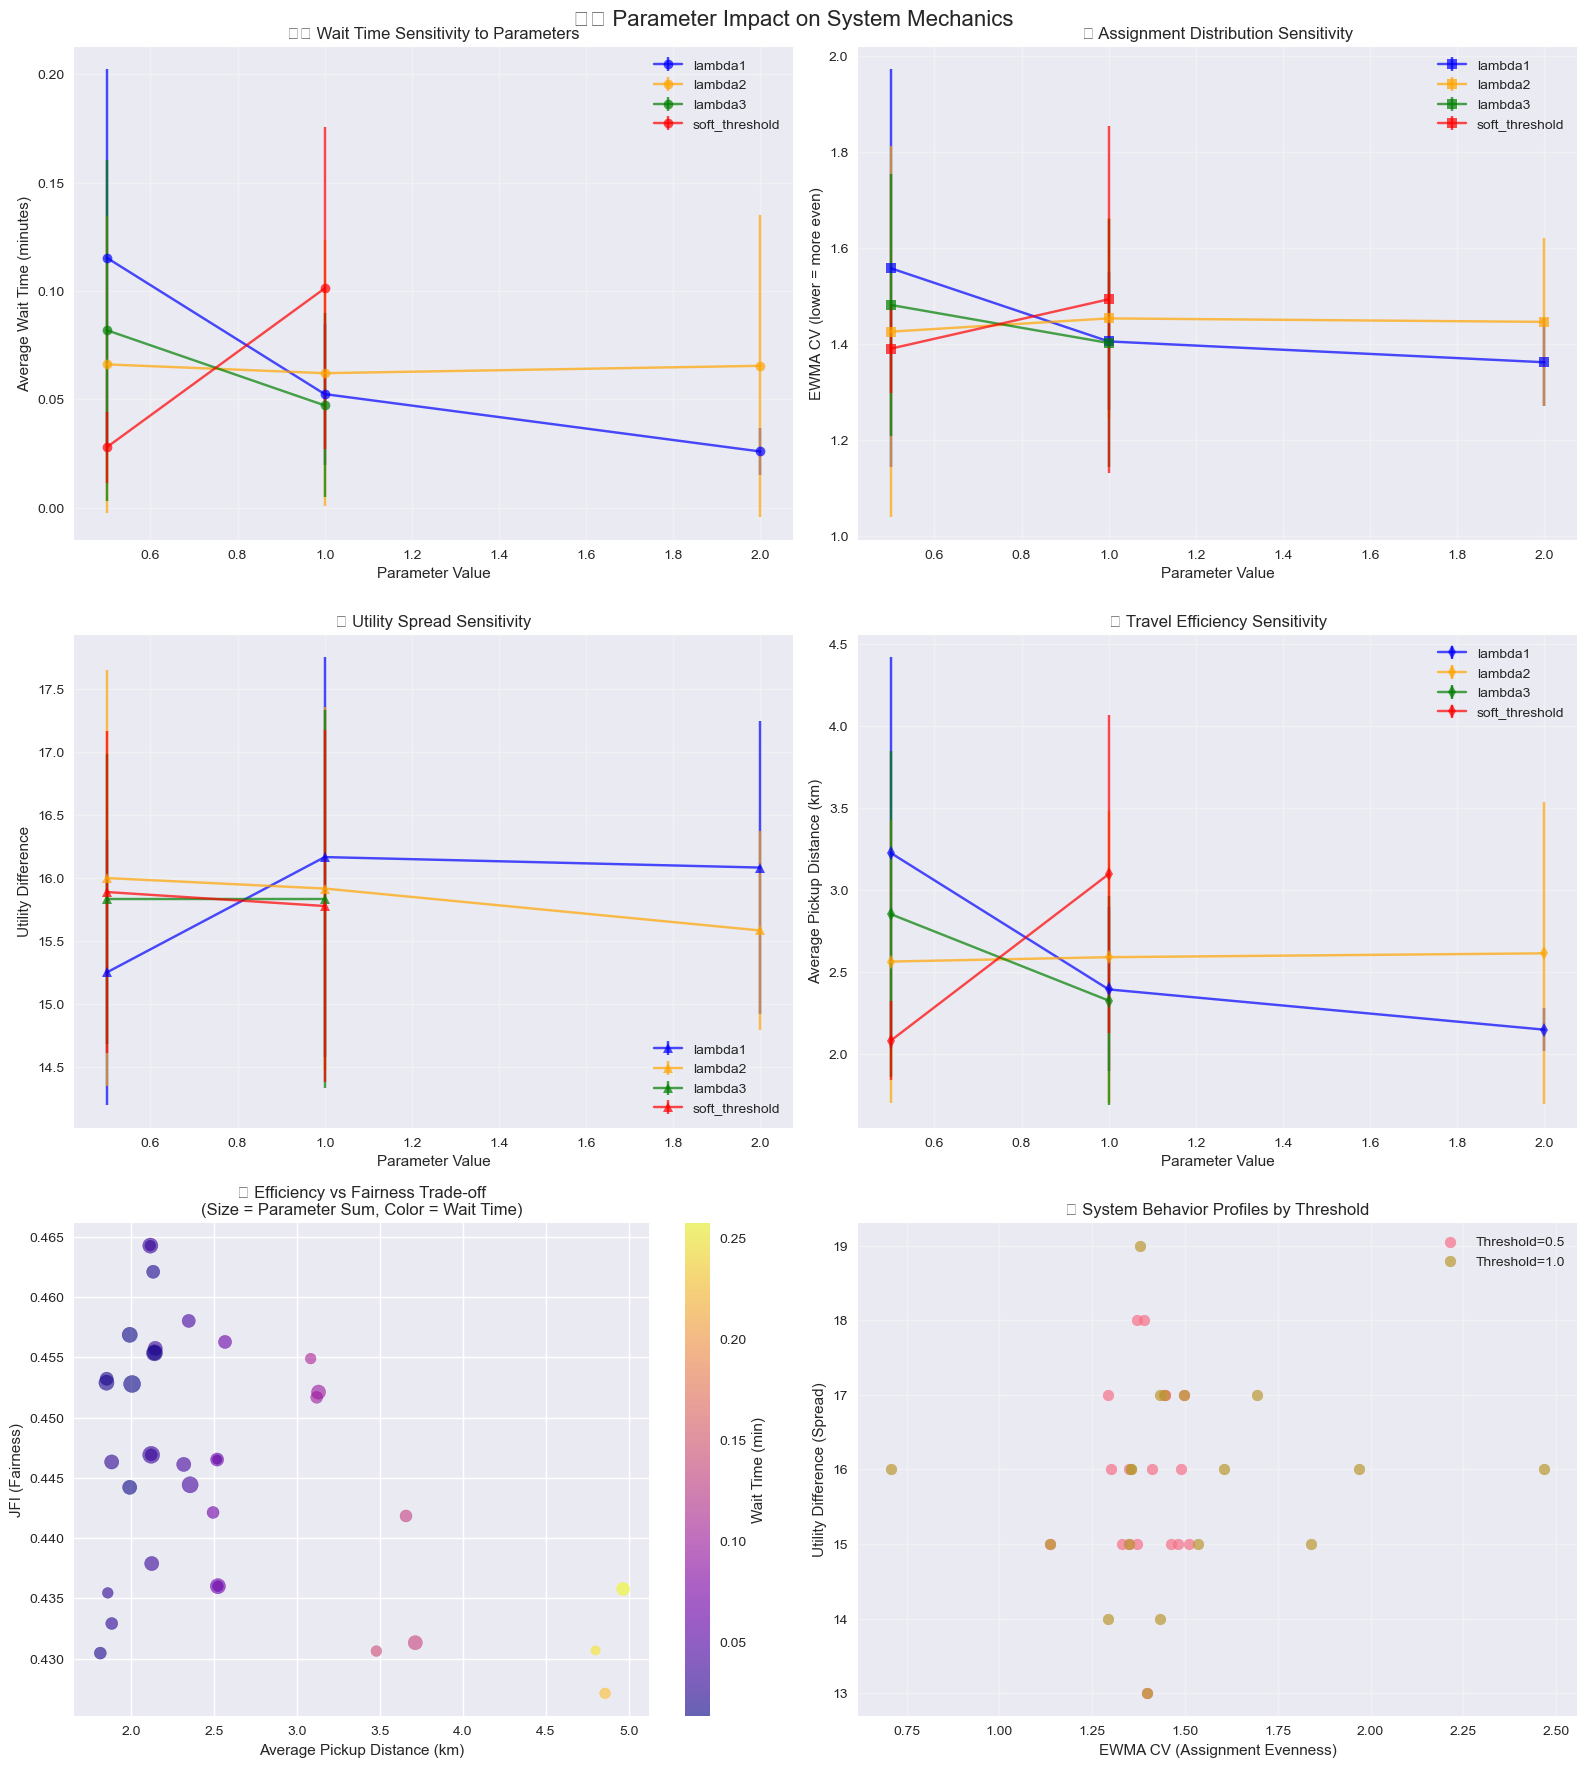


🎯 KEY OPERATIONAL DISCOVERIES:

Parameter with biggest operational impact:
⏱️  Wait Time: lambda1 (range: 0.0894min)
📊 Assignment Evenness: lambda1 (range: 0.1960)
🚗 Travel Distance: lambda1 (range: 1.076km)


In [10]:
# ⚙️ Parameter Impact on System Mechanics

if df is not None:
    print("⚙️ HOW PARAMETERS ACTUALLY CHANGE SYSTEM BEHAVIOR")
    print("=" * 60)
    
    # Create comprehensive parameter impact visualization
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('⚙️ Parameter Impact on System Mechanics', fontsize=16, y=0.98)
    
    # 1. Wait time sensitivity
    param_cols = ['lambda1', 'lambda2', 'lambda3', 'soft_threshold']
    colors = ['blue', 'orange', 'green', 'red']
    
    for i, (param, color) in enumerate(zip(param_cols, colors)):
        param_groups = df.groupby(param)['avg_wait_time'].agg(['mean', 'std']).reset_index()
        axes[0, 0].errorbar(param_groups[param], param_groups['mean'], 
                           yerr=param_groups['std'], label=param, 
                           marker='o', capsize=5, alpha=0.7, color=color)
    
    axes[0, 0].set_xlabel('Parameter Value')
    axes[0, 0].set_ylabel('Average Wait Time (minutes)')
    axes[0, 0].set_title('⏱️ Wait Time Sensitivity to Parameters')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. EWMA CV sensitivity (assignment distribution)
    for i, (param, color) in enumerate(zip(param_cols, colors)):
        param_groups = df.groupby(param)['ewma_cv'].agg(['mean', 'std']).reset_index()
        axes[0, 1].errorbar(param_groups[param], param_groups['mean'], 
                           yerr=param_groups['std'], label=param, 
                           marker='s', capsize=5, alpha=0.7, color=color)
    
    axes[0, 1].set_xlabel('Parameter Value')  
    axes[0, 1].set_ylabel('EWMA CV (lower = more even)')
    axes[0, 1].set_title('📊 Assignment Distribution Sensitivity')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Utility difference sensitivity
    for i, (param, color) in enumerate(zip(param_cols, colors)):
        param_groups = df.groupby(param)['utility_difference'].agg(['mean', 'std']).reset_index()
        axes[1, 0].errorbar(param_groups[param], param_groups['mean'], 
                           yerr=param_groups['std'], label=param, 
                           marker='^', capsize=5, alpha=0.7, color=color)
    
    axes[1, 0].set_xlabel('Parameter Value')
    axes[1, 0].set_ylabel('Utility Difference')
    axes[1, 0].set_title('💰 Utility Spread Sensitivity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Travel efficiency sensitivity
    for i, (param, color) in enumerate(zip(param_cols, colors)):
        param_groups = df.groupby(param)['avg_pickup_distance'].agg(['mean', 'std']).reset_index()
        axes[1, 1].errorbar(param_groups[param], param_groups['mean'], 
                           yerr=param_groups['std'], label=param, 
                           marker='d', capsize=5, alpha=0.7, color=color)
    
    axes[1, 1].set_xlabel('Parameter Value')
    axes[1, 1].set_ylabel('Average Pickup Distance (km)')
    axes[1, 1].set_title('🚗 Travel Efficiency Sensitivity')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 5. Multi-dimensional efficiency analysis
    # Create efficiency vs fairness scatter with size = parameter sum
    scatter = axes[2, 0].scatter(df['avg_pickup_distance'], df['jfi'], 
                                s=df['parameter_sum']*30, # Size based on total parameter weight
                                c=df['avg_wait_time'], cmap='plasma', alpha=0.6)
    axes[2, 0].set_xlabel('Average Pickup Distance (km)')
    axes[2, 0].set_ylabel('JFI (Fairness)')
    axes[2, 0].set_title('🎯 Efficiency vs Fairness Trade-off\n(Size = Parameter Sum, Color = Wait Time)')
    plt.colorbar(scatter, ax=axes[2, 0], label='Wait Time (min)')
    
    # 6. System behavior profile
    # Create a "system behavior fingerprint" for different configurations
    for threshold in sorted(df['soft_threshold'].unique()):
        subset = df[df['soft_threshold'] == threshold]
        axes[2, 1].scatter(subset['ewma_cv'], subset['utility_difference'], 
                          label=f'Threshold={threshold}', alpha=0.7, s=60)
    
    axes[2, 1].set_xlabel('EWMA CV (Assignment Evenness)')
    axes[2, 1].set_ylabel('Utility Difference (Spread)')
    axes[2, 1].set_title('🔍 System Behavior Profiles by Threshold')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n🎯 KEY OPERATIONAL DISCOVERIES:")
    print("=" * 50)
    
    # Calculate which parameters have the biggest operational impact
    param_impacts = {}
    for param in param_cols:
        wait_impact = df.groupby(param)['avg_wait_time'].mean().max() - df.groupby(param)['avg_wait_time'].mean().min()
        ewma_impact = df.groupby(param)['ewma_cv'].mean().max() - df.groupby(param)['ewma_cv'].mean().min()
        distance_impact = df.groupby(param)['avg_pickup_distance'].mean().max() - df.groupby(param)['avg_pickup_distance'].mean().min()
        
        param_impacts[param] = {
            'wait_impact': wait_impact,
            'evenness_impact': ewma_impact,
            'distance_impact': distance_impact
        }
    
    print(f"\nParameter with biggest operational impact:")
    
    # Most impactful for wait time
    biggest_wait_impact = max(param_impacts.items(), key=lambda x: x[1]['wait_impact'])
    print(f"⏱️  Wait Time: {biggest_wait_impact[0]} (range: {biggest_wait_impact[1]['wait_impact']:.4f}min)")
    
    # Most impactful for assignment evenness
    biggest_evenness_impact = max(param_impacts.items(), key=lambda x: x[1]['evenness_impact'])
    print(f"📊 Assignment Evenness: {biggest_evenness_impact[0]} (range: {biggest_evenness_impact[1]['evenness_impact']:.4f})")
    
    # Most impactful for travel efficiency
    biggest_distance_impact = max(param_impacts.items(), key=lambda x: x[1]['distance_impact'])
    print(f"🚗 Travel Distance: {biggest_distance_impact[0]} (range: {biggest_distance_impact[1]['distance_impact']:.3f}km)")
    
else:
    print("❌ No data available for mechanics analysis")